## EuroSAT Project
### Members: Katie Knox, Helen Xu, Ezra Rwakazooba
#### Submission date:  April 5th, 2026

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Change on your computer for connection
import os
%cd "/content/drive/MyDrive/Colab Notebooks/EuroStats"
os.getcwd()

/content/drive/MyDrive/Colab Notebooks/EuroStats


'/content/drive/MyDrive/Colab Notebooks/EuroStats'

In [7]:
import zipfile
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from io import BytesIO

### 1. Data Loading, Processing, and Exploration

#### 1.1 Data Preparation

Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [8]:
ZIP_PATH = r"data/EuroSAT_MS.zip"
EXTRACT_DIR = Path("/content/EuroSAT_MS")

# Extract zip if not already done
if not EXTRACT_DIR.exists():
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR.parent)
    print("Done.")
else:
    print("Already extracted.")

Extracting zip...
Done.


In [9]:
# Build list of (file_path, label) pairs from folder names
samples = []
classes = sorted([d.name for d in EXTRACT_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    cls_dir = EXTRACT_DIR / cls
    for img_path in sorted(cls_dir.glob("*.tif")):
        samples.append((img_path, class_to_idx[cls]))

print(f"Classes ({len(classes)}): {classes}")
print(f"Total images: {len(samples)}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


In [10]:
from collections import Counter

label_counts = Counter(label for _, label in samples)
counts = [label_counts[class_to_idx[cls]] for cls in classes]
total = sum(counts)

for cls, idx in class_to_idx.items():
    class_pcts = np.round(label_counts[idx] / total * 100, 1)
    print(f"  {cls:25s}: {label_counts[idx]:,} images ({class_pcts}%)")

  AnnualCrop               : 3,000 images (11.1%)
  Forest                   : 3,000 images (11.1%)
  HerbaceousVegetation     : 3,000 images (11.1%)
  Highway                  : 2,500 images (9.3%)
  Industrial               : 2,500 images (9.3%)
  Pasture                  : 2,000 images (7.4%)
  PermanentCrop            : 2,500 images (9.3%)
  Residential              : 3,000 images (11.1%)
  River                    : 2,500 images (9.3%)
  SeaLake                  : 3,000 images (11.1%)


<font color='turquoise'>
The dataset has *27000* samples with good class balance.
AnnualCrop, Forest, HerbaceousVegetation, Residential and SeaLake all balance (3,000 samples, ~11.1%), while Highway, Industrial,  PermanentCrop and River   (2500 samples ~9.3%) and Pasture being the least class (2000 samples ~7.4%)
</font>


/tmp/ipykernel_137208/2971806986.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=30, ha="right")


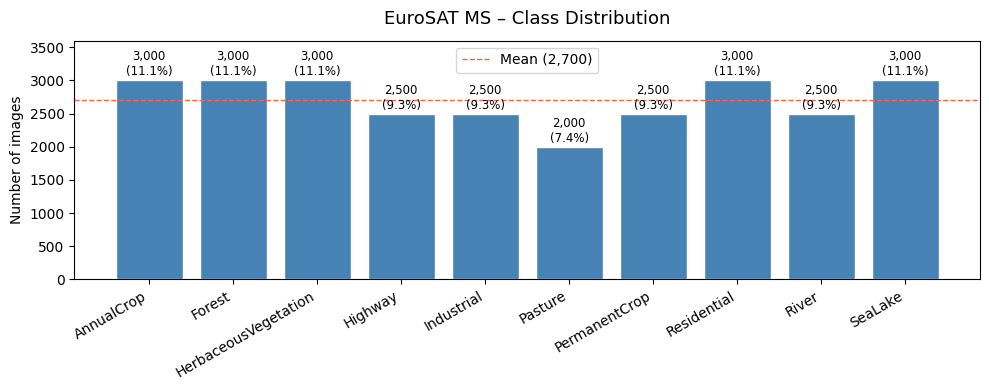

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, counts, color="steelblue", edgecolor="white")

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({count / total:.1%})",
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

mean_count = total // len(classes)
ax.axhline(
    mean_count,
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({mean_count:,})",
)
ax.set_title("EuroSAT MS – Class Distribution", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(counts) * 1.2)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### Plotting one image from each class in a 2x5 grid.

In [11]:
def load_image(path):
    """Load a multispectral GeoTIFF as a (bands, H, W) numpy array."""
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)  # shape: (13, 64, 64)

# Inspect a single image
img_path, label = samples[0]
img = load_image(img_path)
print(f"Image shape : {img.shape}  (bands, H, W)")
print(f"Label       : {label} ({classes[label]})")
print(f"Value range : {img.min():.0f} – {img.max():.0f}")

Image shape : (13, 64, 64)  (bands, H, W)
Label       : 0 (AnnualCrop)
Value range : 9 – 3490


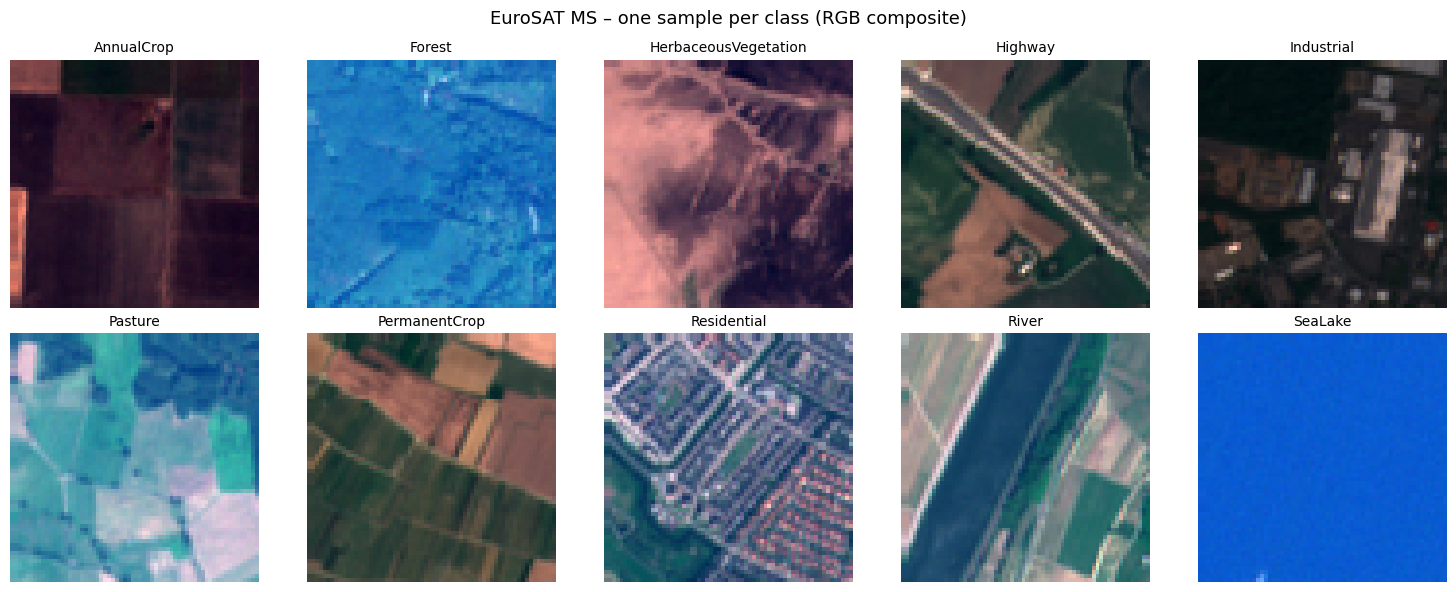

In [12]:
# Sentinel-2 band reference
BAND_NAMES = [
    "B01 (Coastal)", "B02 (Blue)", "B03 (Green)", "B04 (Red)",
    "B05 (Red Edge 1)", "B06 (Red Edge 2)", "B07 (Red Edge 3)",
    "B08 (NIR)", "B08A (Narrow NIR)", "B09 (Water Vapor)",
    "B10 (SWIR Cirrus)", "B11 (SWIR 1)", "B12 (SWIR 2)"
]

# Display one sample per class using RGB (B04, B03, B02)
RED, GREEN, BLUE = 3, 2, 1  # band indices (0-based)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    # Grab first sample of this class
    path, _ = next((s, l) for s, l in samples if classes[l] == cls)
    img = load_image(path)

    # Build RGB composite and normalise to [0, 1]
    rgb = np.stack([img[RED], img[GREEN], img[BLUE]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    axes[i].imshow(rgb)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.suptitle("EuroSAT MS – one sample per class (RGB composite)", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Data Augmentation

To avoid data leakage, the original images are **split into training and testing sets first**, and **augmentation is applied only to the training set**.  
This keeps transformed versions of the same original image from appearing in both train and test data.

Below, I:
1. split the original dataset into train/test sets using stratified sampling,
2. create augmented copies only for the training images,
3. keep the test set unchanged,
4. visualize the resulting modeling dataset.

<font color='turquoise'> The data augmentation method we propose are the following;
<br>

<ol>
    <li> Rotating (0-180) degrees
    <li> Zoom
    <li> width shift
    <li> Height shift
</ol>
</font>

In [13]:
from scipy.ndimage import rotate, shift
from scipy.ndimage import zoom as sp_zoom
from tqdm.notebook import tqdm

In [14]:
def load_image(path: Path) -> np.ndarray:
    """Load a .tif or augmented .npy file as a (bands, H, W) float32 array."""
    path = Path(path)
    if path.suffix == ".npy":
        return np.load(path).astype(np.float32)
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)

In [15]:
def augment_rotate(img: np.ndarray, angle: float = 30.0) -> np.ndarray:
    """Rotate image by angle degrees in the spatial (H, W) plane."""
    return rotate(img, angle, axes=(1, 2), reshape=False)


def augment_zoom(img: np.ndarray, factor: float = 1.2) -> np.ndarray:
    """Zoom in by factor and centre-crop back to the original spatial size."""
    _, h, w = img.shape
    zoomed = sp_zoom(img, [1.0, factor, factor])
    _, zh, zw = zoomed.shape
    ch, cw = (zh - h) // 2, (zw - w) // 2
    return zoomed[:, ch : ch + h, cw : cw + w]


def augment_width_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image horizontally by shift_px pixels."""
    return shift(img, [0, 0, shift_px])


def augment_height_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image vertically by shift_px pixels."""
    return shift(img, [0, shift_px, 0])

# for Size I will only use rotate and zoom, as the shifts cause too much blank space around the edges which is not ideal for a small 64x64 image. I will keep the shift functions in case I want to experiment with them later, but I will comment them out of the AUGMENTATIONS dict for now.
AUGMENTATIONS = {
    "rotate": augment_rotate,
    # "zoom": augment_zoom,
    #"width_shift": augment_width_shift,
    #"height_shift": augment_height_shift,
}

In [16]:
# Split the ORIGINAL dataset first (before augmentation) to avoid data leakage
from sklearn.model_selection import train_test_split

orig_paths = [path for path, _ in samples]
orig_labels = [label for _, label in samples]

train_paths, test_paths, y_train_orig, y_test_orig = train_test_split(
    orig_paths,
    orig_labels,
    test_size=0.4,
    random_state=42,
    stratify=orig_labels
)

train_samples_orig = list(zip(train_paths, y_train_orig))
test_samples_orig = list(zip(test_paths, y_test_orig))

print(f"Original training samples: {len(train_samples_orig):,}")
print(f"Original testing samples : {len(test_samples_orig):,}")

Original training samples: 16,200
Original testing samples : 10,800


In [17]:
# NO NEED TO RUN --> Data created!
# Create a separate augmentation folder for TRAINING data only
AUG_DIR = Path("data/augmented_train_only")
AUG_DIR.mkdir(parents=True, exist_ok=True)

for cls in classes:
    (AUG_DIR / cls).mkdir(parents=True, exist_ok=True)

train_aug_samples = []

for path, lbl in tqdm(train_samples_orig, desc="Augmenting training set only"):
    cls = classes[lbl]
    img = load_image(path)
    stem = Path(path).stem

    for aug_name, aug_fn in AUGMENTATIONS.items():
        out_path = AUG_DIR / cls / f"{stem}_{aug_name}.npy"
        if not out_path.exists():
            np.save(out_path, aug_fn(img))
        train_aug_samples.append((str(out_path), lbl))

print(f"Augmented training samples created/loaded: {len(train_aug_samples):,}")

Augmenting training set only:   0%|          | 0/16200 [00:00<?, ?it/s]

Augmented training samples created/loaded: 16,200


In [18]:
# RUN THIS to GET the DATA
from pathlib import Path

AUG_DIR = Path("data/augmented_train_only")

train_aug_samples = []

for lbl, cls in enumerate(classes):
    cls_dir = AUG_DIR / cls
    aug_files = sorted(cls_dir.glob("*.npy"))
    train_aug_samples.extend([(str(p), lbl) for p in aug_files])

print("Reloaded augmented training samples:", len(train_aug_samples))
print("Example:", train_aug_samples[0])

Reloaded augmented training samples: 16200
Example: ('data/augmented_train_only/AnnualCrop/AnnualCrop_1004_rotate.npy', 0)


In [19]:
# Final modeling splits
train_samples = train_samples_orig + train_aug_samples
test_samples = test_samples_orig

print(f"Train (original only) : {len(train_samples_orig):,}")
print(f"Train (augmented only): {len(train_aug_samples):,}")
print(f"Train (final total)   : {len(train_samples):,}")
print(f"Test  (unchanged)     : {len(test_samples):,}")

Train (original only) : 16,200
Train (augmented only): 16,200
Train (final total)   : 32,400
Test  (unchanged)     : 10,800


In [20]:
# Combined dataset summary for reference
modeling_samples = train_samples + test_samples

print(f"Original dataset size : {len(samples):,}")
print(f"Modeling dataset size : {len(modeling_samples):,}")

Original dataset size : 27,000
Modeling dataset size : 43,200


In [21]:
# Class distribution after augmenting ONLY the training split
train_label_counts = Counter(label for _, label in train_samples)
test_label_counts = Counter(label for _, label in test_samples)
all_label_counts = Counter(label for _, label in modeling_samples)

print("Training distribution:")
for cls, idx in class_to_idx.items():
    pct = np.round(train_label_counts[idx] / len(train_samples) * 100, 1)
    print(f"  {cls:25s}: {train_label_counts[idx]:,} images ({pct}%)")

print("\nTesting distribution:")
for cls, idx in class_to_idx.items():
    pct = np.round(test_label_counts[idx] / len(test_samples) * 100, 1)
    print(f"  {cls:25s}: {test_label_counts[idx]:,} images ({pct}%)")

Training distribution:
  AnnualCrop               : 3,600 images (11.1%)
  Forest                   : 3,600 images (11.1%)
  HerbaceousVegetation     : 3,600 images (11.1%)
  Highway                  : 3,000 images (9.3%)
  Industrial               : 3,000 images (9.3%)
  Pasture                  : 2,400 images (7.4%)
  PermanentCrop            : 3,000 images (9.3%)
  Residential              : 3,600 images (11.1%)
  River                    : 3,000 images (9.3%)
  SeaLake                  : 3,600 images (11.1%)

Testing distribution:
  AnnualCrop               : 1,200 images (11.1%)
  Forest                   : 1,200 images (11.1%)
  HerbaceousVegetation     : 1,200 images (11.1%)
  Highway                  : 1,000 images (9.3%)
  Industrial               : 1,000 images (9.3%)
  Pasture                  : 800 images (7.4%)
  PermanentCrop            : 1,000 images (9.3%)
  Residential              : 1,200 images (11.1%)
  River                    : 1,000 images (9.3%)
  SeaLake       

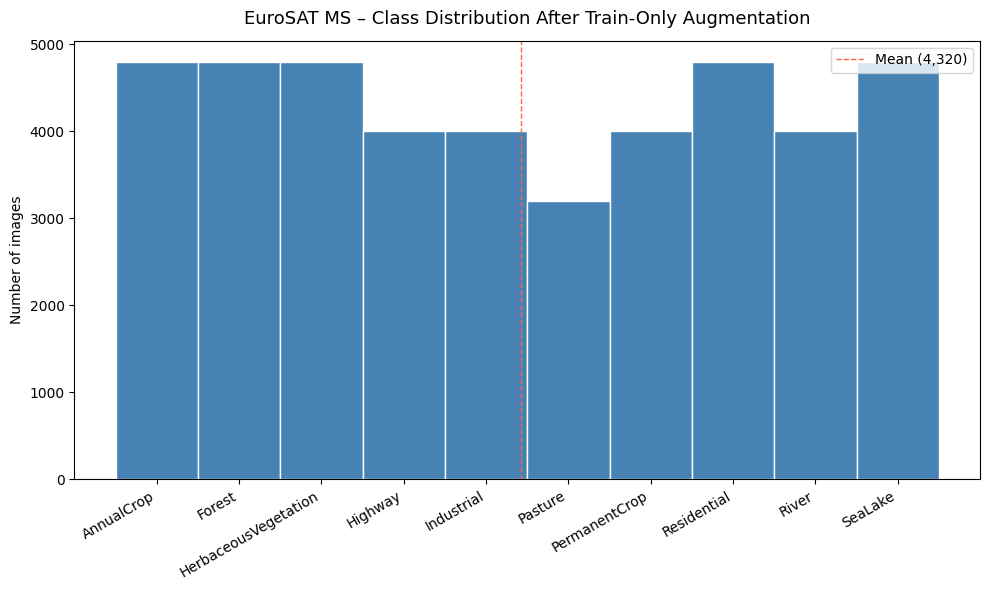

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

label_series = [label for _, label in modeling_samples]
ax.hist(
    label_series,
    bins=len(classes),
    range=(-0.5, len(classes) - 0.5),
    color="steelblue",
    edgecolor="white",
)

all_total = len(modeling_samples)
all_mean = all_total // len(classes)

ax.axvline(
    np.mean(label_series),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({all_mean:,})",
)
ax.set_title("EuroSAT MS – Class Distribution After Train-Only Augmentation", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

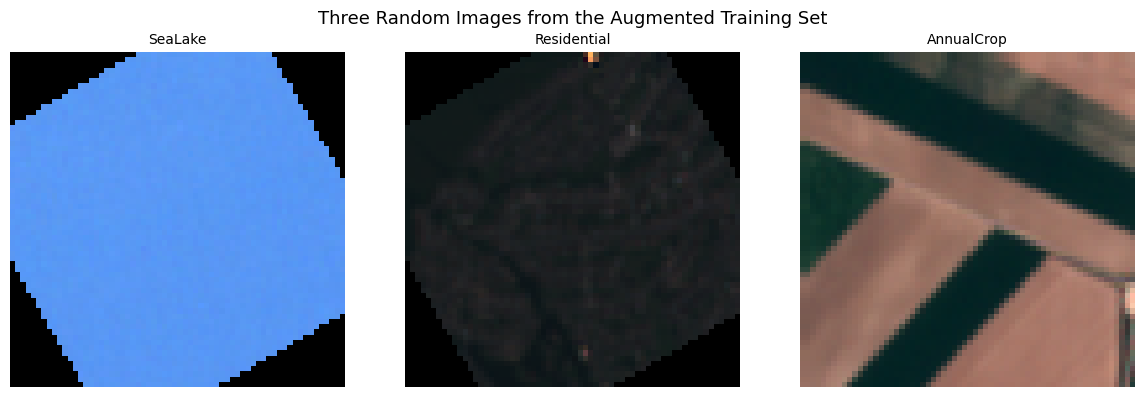

In [23]:
import random

def load_any_image(path):
    """
    Load either:
    - original .tif image -> return RGB composite from MS bands
    - augmented .npy image -> load directly
    Returns image in (H, W, 3), normalized to [0, 1]
    """
    path = Path(path)

    if path.suffix == ".npy":
        img = np.load(path)

        if img.ndim == 3 and img.shape[0] == 13:
            rgb = np.stack([img[3], img[2], img[1]], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 3:
            rgb = img
        else:
            raise ValueError(f"Unexpected .npy shape: {img.shape}")
    else:
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)
        rgb = np.stack([img[3], img[2], img[1]], axis=-1)

    rgb = rgb.astype(np.float32)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    return rgb

# show three random images from the TRAINING set after augmentation
random_samples = random.sample(train_samples, 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (img_path, label) in zip(axes, random_samples):
    rgb = load_any_image(img_path)
    ax.imshow(rgb)
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.suptitle("Three Random Images from the Augmented Training Set", fontsize=13)
plt.tight_layout()
plt.show()

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [24]:
import dask
from dask import delayed
from dask.diagnostics import ProgressBar
from sklearn.model_selection import train_test_split

In [ ]:
# NO NEED TO RUN
# Too Many Samples, ignore the following three chunk, only use the need samples

'''
@delayed
def load_flat(path: Path) -> np.ndarray:
    """Load one image and flatten to a 1-D (bands × H × W) float32 array."""
    return load_image(path).flatten()


y = np.array([lbl for _, lbl in all_samples], dtype=np.int32)
lazy_rows = [load_flat(path) for path, _ in all_samples]

with ProgressBar():
    rows = dask.compute(*lazy_rows, scheduler="threads")

X = np.stack(rows).astype(np.float32)

print(f"X shape : {X.shape}  (n={X.shape[0]:,} samples, p={X.shape[1]:,} pixels)")
print(f"y shape : {y.shape}")
print(f"RAM     : {X.nbytes / 1e9:.1f} GB")

'''

KeyboardInterrupt: 

In [ ]:
# NO NEED TO RUN
'''
indices = np.arange(len(all_samples))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices, y, test_size=0.4, stratify=y, random_state=42
)

X_train, X_test = X[idx_train], X[idx_test]

print(f"Train : X={X_train.shape},  y={y_train.shape}")
print(f"Test  : X={X_test.shape},   y={y_test.shape}")
'''

Train : X=(32400, 53248),  y=(32400,)
Test  : X=(21600, 53248),   y=(21600,)


In [ ]:
# NO NEED TO RUN
'''
# Reshape to (n, 13, 64, 64) to isolate visible RGB bands
n = X.shape[0]
X_cube = X.reshape(n, 13, 64, 64)

# Luminance-weighted grayscale from B04 (Red), B03 (Green), B02 (Blue)
R = X_cube[:, 3].reshape(n, -1)
G = X_cube[:, 2].reshape(n, -1)
B = X_cube[:, 1].reshape(n, -1)

X_gray = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(np.float32)

X_gray_train = X_gray[idx_train]
X_gray_test = X_gray[idx_test]

print(f"X_gray       : {X_gray.shape}  ({X_gray.nbytes / 1e9:.1f} GB)")
print(f"X_gray_train : {X_gray_train.shape}")
print(f"X_gray_test  : {X_gray_test.shape}")
'''

X_gray       : (54000, 4096)  (0.9 GB)
X_gray_train : (32400, 4096)
X_gray_test  : (21600, 4096)


In [25]:
# Extract Forest / Residential / Industrial separately for train and test
target_classes = ["Forest", "Residential", "Industrial"]
target_idx = [class_to_idx[c] for c in target_classes]

train_subset_samples = [(path, lbl) for path, lbl in train_samples if lbl in target_idx]
test_subset_samples = [(path, lbl) for path, lbl in test_samples if lbl in target_idx]

print("Selected classes:", target_classes)
print("Class indices:", target_idx)
print("Train subset size:", len(train_subset_samples))
print("Test subset size :", len(test_subset_samples))

Selected classes: ['Forest', 'Residential', 'Industrial']
Class indices: [1, 7, 4]
Train subset size: 10200
Test subset size : 3400


In [26]:
# check path
print(samples[0][0])
print(train_aug_samples[0][0])

print(Path(samples[0][0]).exists())
print(Path(train_aug_samples[0][0]).exists())

/content/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif
data/augmented_train_only/AnnualCrop/AnnualCrop_1004_rotate.npy
True
True


In [27]:
def load_ms_array(path):
    path = Path(path)

    if path.suffix == ".npy":
        img = np.load(path).astype(np.float32)
        if img.ndim == 3 and img.shape[0] == 13:
            return img
        else:
            raise ValueError(f"Unexpected npy shape for MS data: {img.shape}")

    else:
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)   # (13, H, W)
        return img

In [28]:
from tqdm import tqdm

def ms_to_rgb(ms_img):
    # Sentinel-2: B04, B03, B02 -> R, G, B
    return np.stack([ms_img[3], ms_img[2], ms_img[1]], axis=-1)

def rgb_to_gray(rgb_img):
    return (
        0.2989 * rgb_img[..., 0] +
        0.5870 * rgb_img[..., 1] +
        0.1140 * rgb_img[..., 2]
    ).astype(np.float32)

def build_gray_dataset(sample_list, desc="Converting MS to grayscale"):
    X_gray, y_out = [], []
    for path, lbl in tqdm(sample_list, desc=desc):
        ms = load_ms_array(path)
        rgb = ms_to_rgb(ms)
        gray = rgb_to_gray(rgb)
        X_gray.append(gray)
        y_out.append(lbl)
    return np.stack(X_gray), np.array(y_out, dtype=np.int32)

X_gray_train, y_train = build_gray_dataset(train_subset_samples, desc="Preparing TRAIN grayscale data")
X_gray_test, y_test = build_gray_dataset(test_subset_samples, desc="Preparing TEST grayscale data")

print("X_gray_train shape:", X_gray_train.shape)
print("X_gray_test shape :", X_gray_test.shape)
print("y_train shape     :", y_train.shape)
print("y_test shape      :", y_test.shape)

Preparing TEST grayscale data: 100%|██████████| 3400/3400 [00:19<00:00, 175.62it/s]


X_gray_train shape: (10200, 64, 64)
X_gray_test shape : (3400, 64, 64)
y_train shape     : (10200,)
y_test shape      : (3400,)


In [29]:
# flatten
X_train = X_gray_train.reshape(X_gray_train.shape[0], -1)
X_test = X_gray_test.reshape(X_gray_test.shape[0], -1)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (10200, 4096)
X_test shape : (3400, 4096)


In [30]:
# The split has already been done BEFORE augmentation, so no second split is needed.
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (10200, 4096) (10200,)
Test : (3400, 4096) (3400,)


In [31]:
# Grayscale Faltterned
# store the data in case need to re-run
np.savez(
    "data/dataset_grayscale_flatterned_ML.npz",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

In [32]:
# call the data
data = np.load("data/dataset_grayscale_flatterned_ML.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

### 2. Traditional Machine Learning


#### 2.1 Binary Support Vector Machine
Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

In [24]:
# load packages
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc

In [25]:
# check target class id
target_classes = ["Forest", "Residential", "Industrial"]

for cls in target_classes:
    print(cls, "->", class_to_idx[cls])

Forest -> 1
Residential -> 7
Industrial -> 4


In [40]:
# define model
def run_binary_svm(X_train, X_test, y_train, y_test, class_a, class_b, classes):
    train_mask = np.isin(y_train, [class_a, class_b])
    test_mask = np.isin(y_test, [class_a, class_b])

    X_train_bin = X_train[train_mask]
    X_test_bin = X_test[test_mask]
    y_train_bin = y_train[train_mask]
    y_test_bin = y_test[test_mask]

    y_train_bin01 = np.where(y_train_bin == class_a, 0, 1)
    y_test_bin01 = np.where(y_test_bin == class_a, 0, 1)

    svm = SVC(kernel="linear", random_state=42)
    svm.fit(X_train_bin, y_train_bin01)

    y_pred = svm.predict(X_test_bin)
    y_score = svm.decision_function(X_test_bin)

    acc = accuracy_score(y_test_bin01, y_pred)
    fpr, tpr, _ = roc_curve(y_test_bin01, y_score)
    roc_auc = auc(fpr, tpr)

    mis_idx = np.where(y_pred != y_test_bin01)[0]
    mis_example = None

    if len(mis_idx) > 0:
        i = mis_idx[0]
        mis_example = {
            "image_flat": X_test_bin[i],
            "true_label_name": classes[class_a] if y_test_bin01[i] == 0 else classes[class_b],
            "pred_label_name": classes[class_a] if y_pred[i] == 0 else classes[class_b],
        }

    return {
        "model": svm,
        "class_a_name": classes[class_a],
        "class_b_name": classes[class_b],
        "accuracy": acc,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "mis_example": mis_example,
    }

In [41]:
# call the model
FOREST = 1
RESIDENTIAL = 7
INDUSTRIAL = 4

from tqdm.notebook import tqdm

binary_tasks = [
    ("Forest vs Residential", FOREST, RESIDENTIAL),
    ("Forest vs Industrial", FOREST, INDUSTRIAL),
    ("Residential vs Industrial", RESIDENTIAL, INDUSTRIAL),
]

binary_results = {}

for name, class_a, class_b in tqdm(binary_tasks, desc="Training binary SVMs"):
    binary_results[name] = run_binary_svm(
        X_train, X_test, y_train, y_test,
        class_a, class_b, classes
    )

svm_fr = binary_results["Forest vs Residential"]
svm_fi = binary_results["Forest vs Industrial"]
svm_ri = binary_results["Residential vs Industrial"]

Training binary SVMs:   0%|          | 0/3 [00:00<?, ?it/s]

In [42]:
# Model result: accuracy and AUC
for result in [svm_fr, svm_fi, svm_ri]:
    print(f"{result['class_a_name']} vs {result['class_b_name']}")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  AUC     : {result['auc']:.4f}")
    print()

Forest vs Residential
  Accuracy: 0.9487
  AUC     : 0.9920

Forest vs Industrial
  Accuracy: 0.9964
  AUC     : 1.0000

Residential vs Industrial
  Accuracy: 0.6945
  AUC     : 0.7294



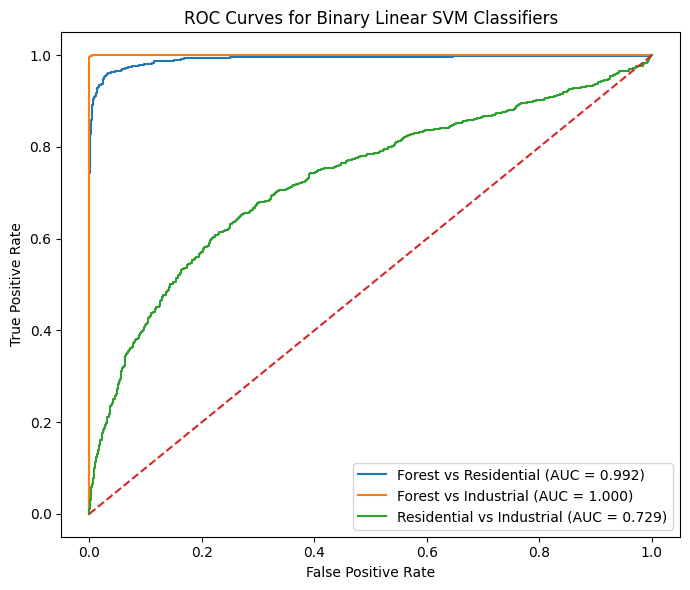

In [ ]:
# ROC curves
plt.figure(figsize=(7, 6))

for result in [svm_fr, svm_fi, svm_ri]:
    plt.plot(
        result["fpr"],
        result["tpr"],
        label=f"{result['class_a_name']} vs {result['class_b_name']} (AUC = {result['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Binary Linear SVM Classifiers")
plt.legend()
plt.tight_layout()
plt.show()

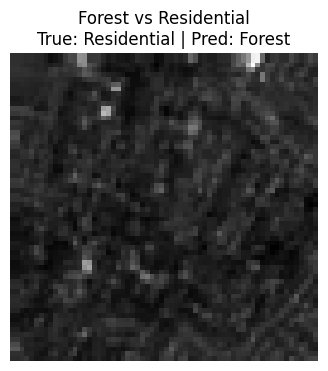

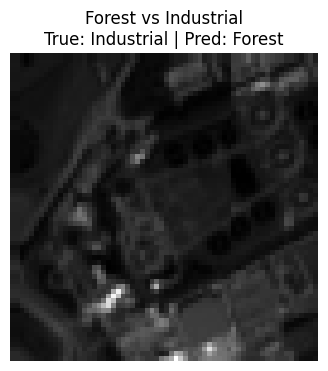

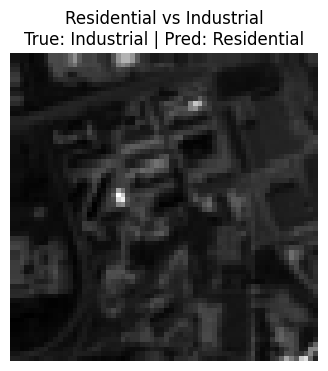

In [ ]:
# missed classification
def plot_misclassified_example(result):
    mis = result["mis_example"]

    if mis is None:
        print(f"No misclassified example found for {result['class_a_name']} vs {result['class_b_name']}.")
        return

    img = mis["image_flat"].reshape(64, 64)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(
        f"{result['class_a_name']} vs {result['class_b_name']}\n"
        f"True: {mis['true_label_name']} | Pred: {mis['pred_label_name']}"
    )
    plt.axis("off")
    plt.show()

for result in [svm_fr, svm_fi, svm_ri]:
    plot_misclassified_example(result)

In [ ]:
# save the result
import joblib
from pathlib import Path

SAVE_DIR = Path("data/saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(svm_fr["model"], SAVE_DIR / "svm_forest_vs_residential.joblib")
joblib.dump(svm_fi["model"], SAVE_DIR / "svm_forest_vs_industrial.joblib")
joblib.dump(svm_ri["model"], SAVE_DIR / "svm_residential_vs_industrial.joblib")

results_to_save = {
    "Forest_vs_Residential": {
        "accuracy": svm_fr["accuracy"],
        "auc": svm_fr["auc"],
        "fpr": svm_fr["fpr"],
        "tpr": svm_fr["tpr"],
        "mis_example": svm_fr["mis_example"],
    },
    "Forest_vs_Industrial": {
        "accuracy": svm_fi["accuracy"],
        "auc": svm_fi["auc"],
        "fpr": svm_fi["fpr"],
        "tpr": svm_fi["tpr"],
        "mis_example": svm_fi["mis_example"],
    },
    "Residential_vs_Industrial": {
        "accuracy": svm_ri["accuracy"],
        "auc": svm_ri["auc"],
        "fpr": svm_ri["fpr"],
        "tpr": svm_ri["tpr"],
        "mis_example": svm_ri["mis_example"],
    },
}

joblib.dump(results_to_save, SAVE_DIR / "binary_svm_results.joblib")

['data/saved_models/binary_svm_results.joblib']

In [ ]:
# To extract the results
'''
split_info = {
    "FOREST": FOREST,
    "RESIDENTIAL": RESIDENTIAL,
    "INDUSTRIAL": INDUSTRIAL,
}

joblib.dump(split_info, SAVE_DIR / "label_info.joblib")
'''

#### 2.2 Multiclass, Majority-Vote SVM
Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

In [ ]:
def get_binary_votes_and_scores(model_dict, X, class_a, class_b):
    """
    For one binary SVM, return:
    - predicted class labels (class_a or class_b)
    - score contribution for class_a and class_b

    Output:
    pred_labels: (N,)
    score_a: (N,)
    score_b: (N,)
    """
    model = model_dict["model"]

    # prediction in 0/1 space
    pred01 = model.predict(X)
    pred_labels = np.where(pred01 == 0, class_a, class_b)

    # score
    if hasattr(model, "predict_proba"):
        prob_b = model.predict_proba(X)[:, 1]
        score_b = prob_b
        score_a = 1 - prob_b
    else:
        # if using decision_function instead of predict_proba
        d = model.decision_function(X)
        prob_b = 1 / (1 + np.exp(-d))   # sigmoid to map into (0,1)
        score_b = prob_b
        score_a = 1 - prob_b

    return pred_labels, score_a, score_b

In [ ]:
def multiclass_majority_vote(X, svm_fr, svm_fi, svm_ri):
    """
    Combine 3 binary one-vs-one SVMs into a 3-class classifier
    using majority voting, with score-based tie breaking.

    Returns:
    y_pred_final: final predicted labels in original class ids
    vote_matrix: vote counts per class
    score_matrix: accumulated confidence scores per class
    """
    class_list = [FOREST, RESIDENTIAL, INDUSTRIAL]
    class_to_col = {FOREST: 0, RESIDENTIAL: 1, INDUSTRIAL: 2}

    n = X.shape[0]
    vote_matrix = np.zeros((n, 3), dtype=int)
    score_matrix = np.zeros((n, 3), dtype=float)

    # Forest vs Residential
    pred_fr, score_f_fr, score_r_fr = get_binary_votes_and_scores(svm_fr, X, FOREST, RESIDENTIAL)
    for i, pred in enumerate(pred_fr):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[FOREST]] += score_f_fr
    score_matrix[:, class_to_col[RESIDENTIAL]] += score_r_fr

    # Forest vs Industrial
    pred_fi, score_f_fi, score_i_fi = get_binary_votes_and_scores(svm_fi, X, FOREST, INDUSTRIAL)
    for i, pred in enumerate(pred_fi):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[FOREST]] += score_f_fi
    score_matrix[:, class_to_col[INDUSTRIAL]] += score_i_fi

    # Residential vs Industrial
    pred_ri, score_r_ri, score_i_ri = get_binary_votes_and_scores(svm_ri, X, RESIDENTIAL, INDUSTRIAL)
    for i, pred in enumerate(pred_ri):
        vote_matrix[i, class_to_col[pred]] += 1
    score_matrix[:, class_to_col[RESIDENTIAL]] += score_r_ri
    score_matrix[:, class_to_col[INDUSTRIAL]] += score_i_ri

    # majority vote with tie-breaking by score sum
    y_pred_final = []
    for i in range(n):
        max_vote = vote_matrix[i].max()
        candidates = np.where(vote_matrix[i] == max_vote)[0]

        if len(candidates) == 1:
            chosen_col = candidates[0]
        else:
            # tie break using highest accumulated score
            chosen_col = candidates[np.argmax(score_matrix[i, candidates])]

        y_pred_final.append(class_list[chosen_col])

    y_pred_final = np.array(y_pred_final)
    return y_pred_final, vote_matrix, score_matrix

In [ ]:
y_pred_mv, vote_matrix, score_matrix = multiclass_majority_vote(
    X_test, svm_fr, svm_fi, svm_ri
)

acc_mv = accuracy_score(y_test, y_pred_mv)
print(f"Majority-vote multiclass SVM accuracy: {acc_mv:.4f}")

Majority-vote multiclass SVM accuracy: 0.7765


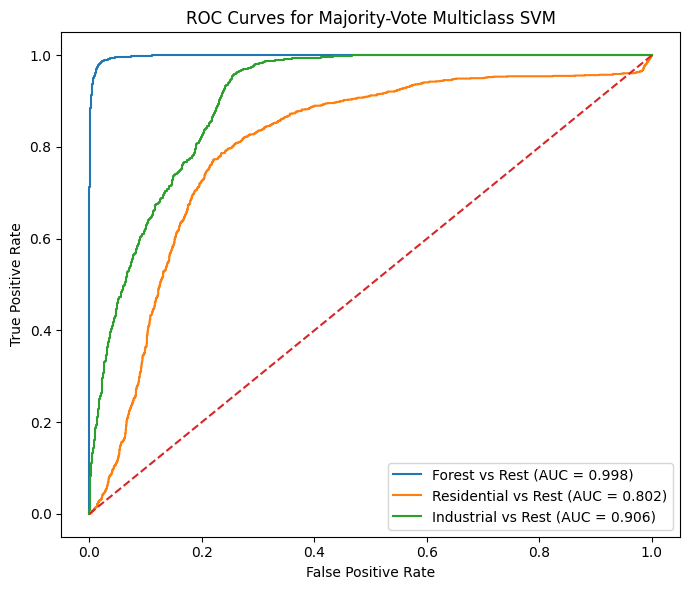

Forest AUC: 0.9985
Residential AUC: 0.8024
Industrial AUC: 0.9060


In [ ]:
# binarize true labels in the same class order
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[FOREST, RESIDENTIAL, INDUSTRIAL])

fpr = {}
tpr = {}
roc_auc = {}

class_names_3 = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

for i, cls_name in enumerate(class_names_3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], score_matrix[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i, cls_name in enumerate(class_names_3):
    plt.plot(
        fpr[i], tpr[i],
        label=f"{cls_name} vs Rest (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Majority-Vote Multiclass SVM")
plt.legend()
plt.tight_layout()
plt.show()

for i, cls_name in enumerate(class_names_3):
    print(f"{cls_name} AUC: {roc_auc[i]:.4f}")

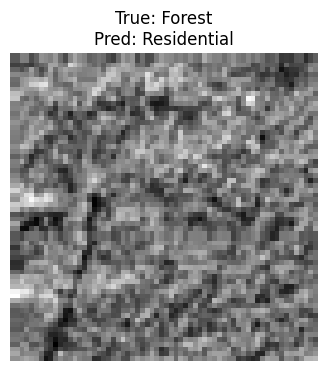

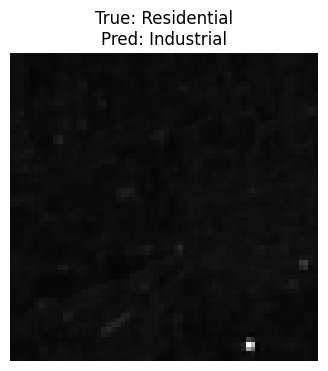

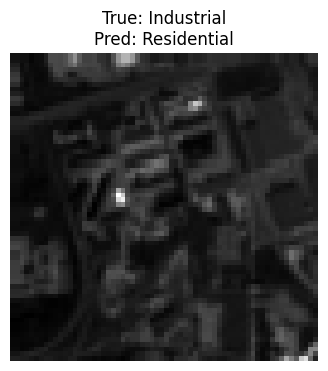

In [ ]:
def plot_one_misclassified_per_true_class(X_test, y_test, y_pred_mv, classes):
    target_classes = [FOREST, RESIDENTIAL, INDUSTRIAL]

    for cls in target_classes:
        mis_idx = np.where((y_test == cls) & (y_pred_mv != y_test))[0]

        if len(mis_idx) == 0:
            print(f"No misclassified example found for true class = {classes[cls]}.")
            continue

        i = mis_idx[0]
        img = X_test[i].reshape(64, 64)

        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap="gray")
        plt.title(
            f"True: {classes[y_test[i]]}\nPred: {classes[y_pred_mv[i]]}"
        )
        plt.axis("off")
        plt.show()

plot_one_misclassified_per_true_class(X_test, y_test, y_pred_mv, classes)



```
# This is formatted as code
```

#### 2.3 Multiclass Random Forest
Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9206


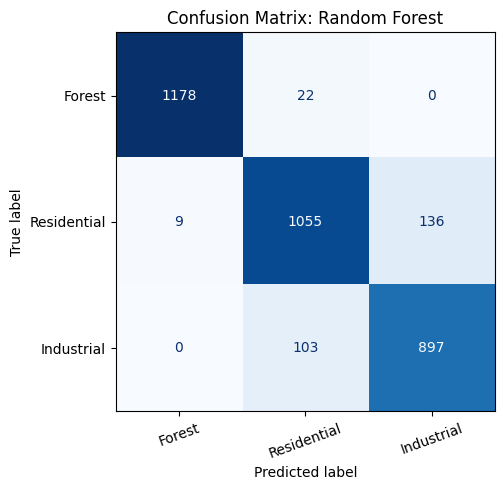

In [ ]:
label_order = [FOREST, RESIDENTIAL, INDUSTRIAL]
label_names = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

cm = confusion_matrix(y_test, y_pred_rf, labels=label_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Random Forest")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

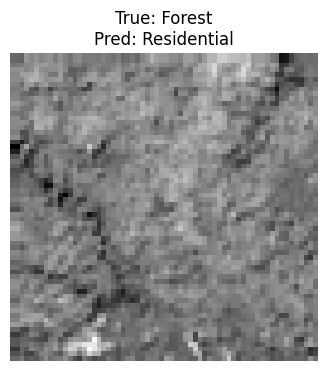

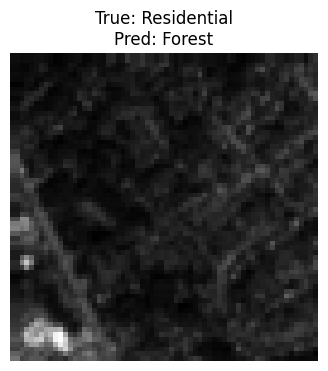

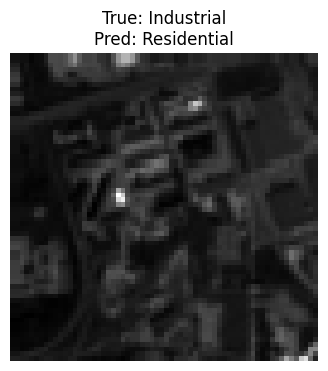

In [ ]:
def plot_rf_misclassified_examples(X_test, y_test, y_pred, classes, class_list):
    for cls in class_list:
        mis_idx = np.where((y_test == cls) & (y_pred != y_test))[0]

        if len(mis_idx) == 0:
            print(f"No misclassified example found for true class = {classes[cls]}.")
            continue

        i = mis_idx[0]
        img = X_test[i].reshape(64, 64)

        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap="gray")
        plt.title(
            f"True: {classes[y_test[i]]}\nPred: {classes[y_pred[i]]}"
        )
        plt.axis("off")
        plt.show()

plot_rf_misclassified_examples(
    X_test, y_test, y_pred_rf,
    classes,
    [FOREST, RESIDENTIAL, INDUSTRIAL]
)

In [ ]:
for cls in [FOREST, RESIDENTIAL, INDUSTRIAL]:
    mis_idx = np.where((y_test == cls) & (y_pred_rf != y_test))[0]

    if len(mis_idx) == 0:
        print(f"{classes[cls]}: no misclassified example found.")
    else:
        i = mis_idx[0]
        print(
            f"{classes[cls]} misclassified example -> "
            f"True: {classes[y_test[i]]}, Predicted: {classes[y_pred_rf[i]]}"
        )

Forest misclassified example -> True: Forest, Predicted: Residential
Residential misclassified example -> True: Residential, Predicted: Forest
Industrial misclassified example -> True: Industrial, Predicted: Residential


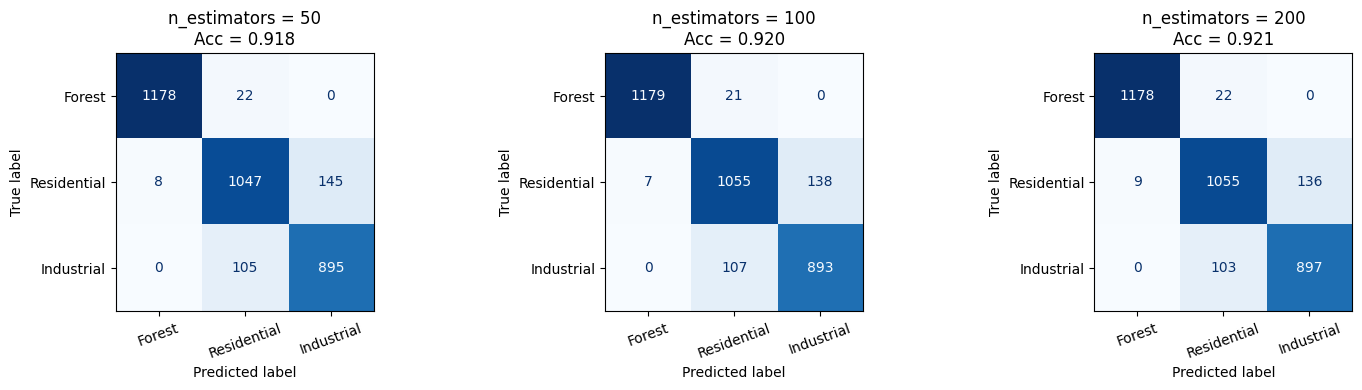

In [ ]:
# compare different estimator and different result
n_list = [50, 100, 200]

label_order = [FOREST, RESIDENTIAL, INDUSTRIAL]
label_names = [classes[FOREST], classes[RESIDENTIAL], classes[INDUSTRIAL]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, n_list):
    # train model
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # predict
    y_pred = rf.predict(X_test)

    # accuracy
    acc = accuracy_score(y_test, y_pred)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=label_order)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"n_estimators = {n}\nAcc = {acc:.3f}")
    ax.set_xticklabels(label_names, rotation=20)

plt.tight_layout()
plt.show()

### 3. Deep Learning

#### 3.1 Greyscale Images
For this section, use the same greyscale images that you used in the traditional machine learning section.


In [59]:
# load grayscale data for the FULL 10-class problem using the leakage-safe split
from tqdm.notebook import tqdm
import numpy as np

def ms_to_rgb(ms_img):
    return np.stack([ms_img[3], ms_img[2], ms_img[1]], axis=-1)

def rgb_to_gray(rgb_img):
    return (
        0.2989 * rgb_img[..., 0] +
        0.5870 * rgb_img[..., 1] +
        0.1140 * rgb_img[..., 2]
    ).astype(np.float32)

def build_gray_dataset(sample_list, desc="Preparing grayscale dataset"):
    X_gray, y_out = [], []
    for path, lbl in tqdm(sample_list, desc=desc):
        ms = load_ms_array(path)
        rgb = ms_to_rgb(ms)
        gray = rgb_to_gray(rgb)
        X_gray.append(gray)
        y_out.append(lbl)
    return np.stack(X_gray), np.array(y_out, dtype=np.int32)

X_gray_train_full, y_train_full = build_gray_dataset(
    train_samples, desc="Preparing full TRAIN grayscale dataset"
)
X_gray_test_full, y_test_full = build_gray_dataset(
    test_samples, desc="Preparing full TEST grayscale dataset"
)

print("X_gray_train_full shape:", X_gray_train_full.shape)
print("X_gray_test_full shape :", X_gray_test_full.shape)
print("y_train_full shape     :", y_train_full.shape)
print("y_test_full shape      :", y_test_full.shape)

Preparing full TRAIN grayscale dataset:   0%|          | 0/32400 [00:00<?, ?it/s]

Preparing full TEST grayscale dataset:   0%|          | 0/10800 [00:00<?, ?it/s]

X_gray_train_full shape: (32400, 64, 64)
X_gray_test_full shape : (10800, 64, 64)
y_train_full shape     : (32400,)
y_test_full shape      : (10800,)


In [60]:
# Flatten
X_train_gray_flat = X_gray_train_full.reshape(X_gray_train_full.shape[0], -1)
X_test_gray_flat = X_gray_test_full.reshape(X_gray_test_full.shape[0], -1)

print("X_train_gray_flat shape:", X_train_gray_flat.shape)
print("X_test_gray_flat shape :", X_test_gray_flat.shape)

X_train_gray_flat shape: (32400, 4096)
X_test_gray_flat shape : (10800, 4096)


In [61]:
# No new split here — data were already split before augmentation
print(X_train_gray_flat.shape, X_test_gray_flat.shape)
print(y_train_full.shape, y_test_full.shape)

(32400, 4096) (10800, 4096)
(32400,) (10800,)


In [67]:
X_train_gray_flat, y_train_full = shuffle(
    X_train_gray_flat,
    y_train_full,
    random_state=42
)

In [68]:
# Normalized
train_max = X_train_gray_flat.max()

X_train_gray_flat_nn = X_train_gray_flat / (train_max + 1e-8)
X_test_gray_flat_nn = X_test_gray_flat / (train_max + 1e-8)

In [69]:
# one-hot encoding
from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_cat = to_categorical(y_train_full, num_classes=num_classes)
y_test_cat = to_categorical(y_test_full, num_classes=num_classes)

print(y_train_cat.shape, y_test_cat.shape)

(32400, 10) (10800, 10)


In [70]:
check_class_balance(np.argmax(y_train_cat, axis=1))


First 80%:
Class 0: 0.113
Class 1: 0.111
Class 2: 0.111
Class 3: 0.092
Class 4: 0.093
Class 5: 0.075
Class 6: 0.093
Class 7: 0.110
Class 8: 0.093
Class 9: 0.109

Last 20%:
Class 0: 0.105
Class 1: 0.111
Class 2: 0.111
Class 3: 0.094
Class 4: 0.092
Class 5: 0.071
Class 6: 0.092
Class 7: 0.115
Class 8: 0.091
Class 9: 0.118


###### 3.1.1 Single-Layer Neural Network
Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

In [71]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [72]:
single_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(len(classes), activation="softmax")
])

single_layer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
single_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
history_single = single_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1294 - loss: 2.2579 - val_accuracy: 0.1372 - val_loss: 2.2371
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1530 - loss: 2.2129 - val_accuracy: 0.1798 - val_loss: 2.1980
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1793 - loss: 2.1799 - val_accuracy: 0.1897 - val_loss: 2.1622
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2027 - loss: 2.1547 - val_accuracy: 0.2278 - val_loss: 2.1390
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2303 - loss: 2.1312 - val_accuracy: 0.1980 - val_loss: 2.1184
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2488 - loss: 2.1116 - val_accuracy: 0.2398 - val_loss: 2.1052
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2468 - loss: 2.0952 - val_accuracy: 0.2142 - val_loss: 2.0838
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2670 - loss: 2.0773 - val_accuracy: 0

In [75]:
test_loss_single, test_acc_single = single_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Single-Layer NN Test Accuracy: {test_acc_single:.4f}")
print(f"Single-Layer NN Test Loss: {test_loss_single:.4f}")

Single-Layer NN Test Accuracy: 0.3055
Single-Layer NN Test Loss: 1.8812


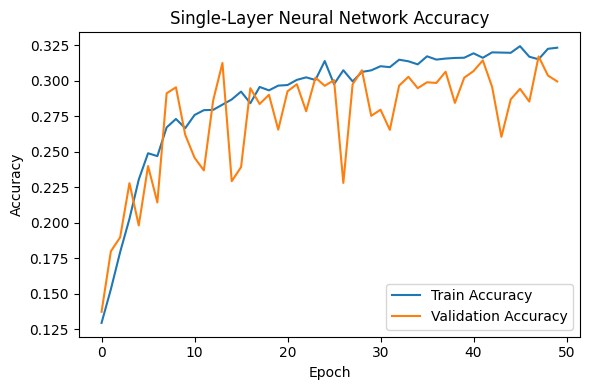

In [76]:
import matplotlib.pyplot as plt
# Accuracy visualization
plt.figure(figsize=(6, 4))
plt.plot(history_single.history["accuracy"], label="Train Accuracy")
plt.plot(history_single.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Single-Layer Neural Network Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

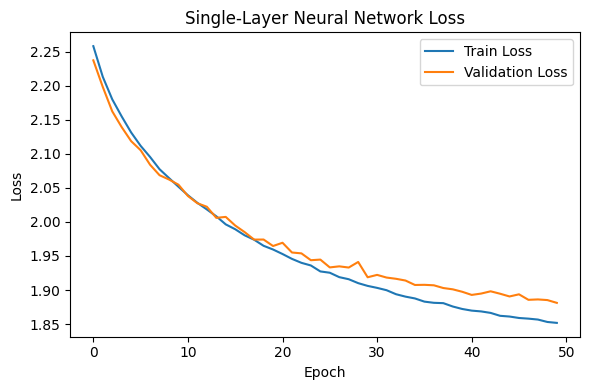

In [77]:
# Loss visualization
plt.figure(figsize=(6, 4))
plt.plot(history_single.history["loss"], label="Train Loss")
plt.plot(history_single.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single-Layer Neural Network Loss")
plt.legend()
plt.tight_layout()
plt.show()

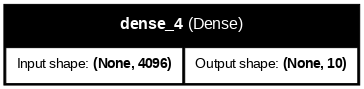

In [78]:

from tensorflow.keras.utils import plot_model

plot_model(
    single_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)


###### 3.1.2 Two-Layer Neural Network
Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

In [79]:
# from tensorflow import keras
from tensorflow.keras import layers

two_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(classes), activation="softmax")
])

two_layer_model.summary()
from tensorflow import keras
from tensorflow.keras import layers

two_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(128, activation="relu"), # hidden layer 128 nodes relu
    layers.Dense(len(classes), activation="softmax") # output layer 10 nodes
])

two_layer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# complie model
two_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [81]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_two = two_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1467 - loss: 2.2242 - val_accuracy: 0.2485 - val_loss: 2.1619
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2407 - loss: 2.1007 - val_accuracy: 0.2630 - val_loss: 2.0367
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2740 - loss: 1.9787 - val_accuracy: 0.2603 - val_loss: 1.9231
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.2907 - loss: 1.9034 - val_accuracy: 0.2684 - val_loss: 1.8801
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2945 - loss: 1.8615 - val_accuracy: 0.3014 - val_loss: 1.8485
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2990 - loss: 1.8436 - val_accuracy: 0.2903 - val_loss: 1.8840
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3010 - loss: 1.8230 - val_accuracy: 0.2853 - val_loss: 1.8109
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3070 - loss: 1.8034 - val_accu

In [82]:
test_loss_two, test_acc_two = two_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Two-Layer NN Test Accuracy: {test_acc_two:.4f}")
print(f"Two-Layer NN Test Loss: {test_loss_two:.4f}")

Two-Layer NN Test Accuracy: 0.3994
Two-Layer NN Test Loss: 1.5847


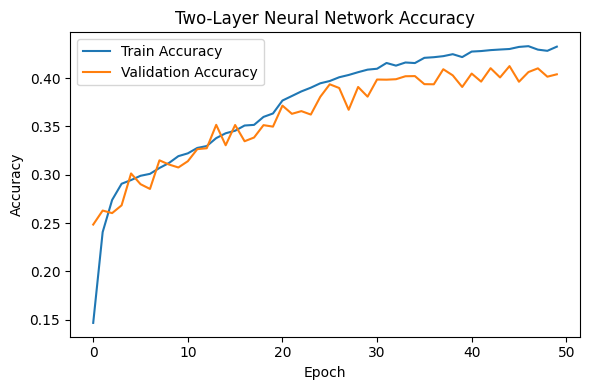

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_two.history["accuracy"], label="Train Accuracy")
plt.plot(history_two.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Two-Layer Neural Network Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

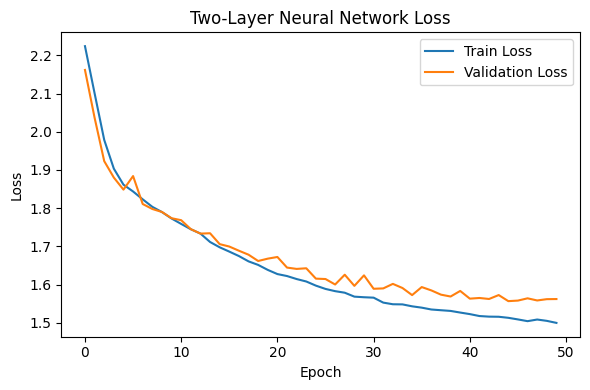

In [84]:
plt.figure(figsize=(6, 4))
plt.plot(history_two.history["loss"], label="Train Loss")
plt.plot(history_two.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Two-Layer Neural Network Loss")
plt.legend()
plt.tight_layout()
plt.show()

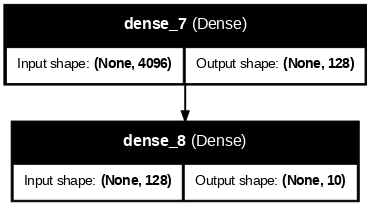

In [85]:

from tensorflow.keras.utils import plot_model

plot_model(
    two_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)

###### 3.1.3 Four-Layer Neural Network with Dropout
Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.



In [86]:
# define 4-layer model
from tensorflow import keras
from tensorflow.keras import layers

four_layer_model = keras.Sequential([
    layers.Input(shape=(4096,)),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(classes), activation="softmax")
])

four_layer_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,634 (4.16 MB)

 Trainable params: 1,090,634 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
four_layer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [88]:
from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=4,
#     restore_best_weights=True
# )

history_four = four_layer_model.fit(
    X_train_gray_flat_nn,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.1624 - loss: 2.2085 - val_accuracy: 0.2517 - val_loss: 1.9920
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.2383 - loss: 1.9725 - val_accuracy: 0.2543 - val_loss: 1.9087
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2681 - loss: 1.8833 - val_accuracy: 0.3042 - val_loss: 1.8176
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2913 - loss: 1.8401 - val_accuracy: 0.2934 - val_loss: 1.8452
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.3077 - loss: 1.8029 - val_accuracy: 0.3261 - val_loss: 1.7648
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3219 - loss: 1.7839 - val_accuracy: 0.2961 - val_loss: 1.8524
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.3297 - loss: 1.7715 - val_accuracy: 0.3296 - val_loss: 1.7274
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3328 - loss: 1.7552 - val_accu

In [89]:
test_loss_four, test_acc_four = four_layer_model.evaluate(
    X_test_gray_flat_nn,
    y_test_cat,
    verbose=0
)

print(f"Four-Layer NN with Dropout Test Accuracy: {test_acc_four:.4f}")
print(f"Four-Layer NN with Dropout Test Loss: {test_loss_four:.4f}")

Four-Layer NN with Dropout Test Accuracy: 0.3478
Four-Layer NN with Dropout Test Loss: 1.7550


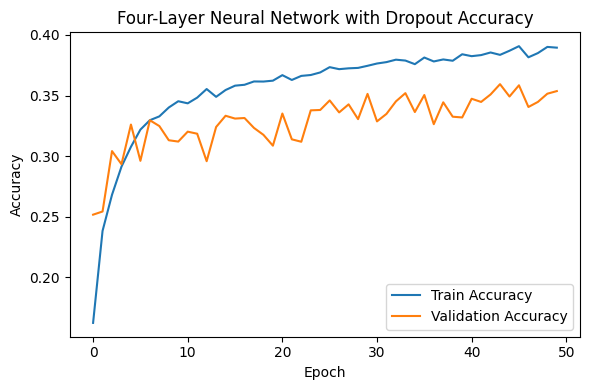

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_four.history["accuracy"], label="Train Accuracy")
plt.plot(history_four.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Four-Layer Neural Network with Dropout Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

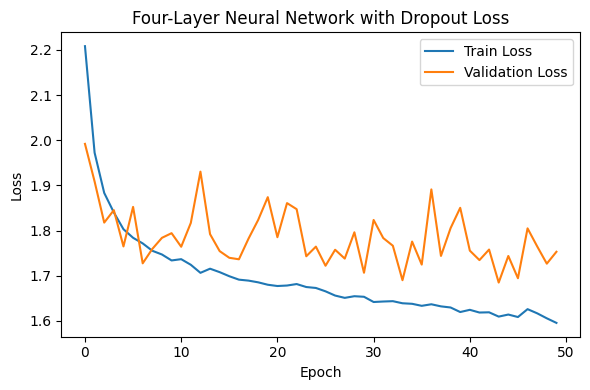

In [93]:
plt.figure(figsize=(6, 4))
plt.plot(history_four.history["loss"], label="Train Loss")
plt.plot(history_four.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Four-Layer Neural Network with Dropout Loss")
plt.legend()
plt.tight_layout()
plt.show()

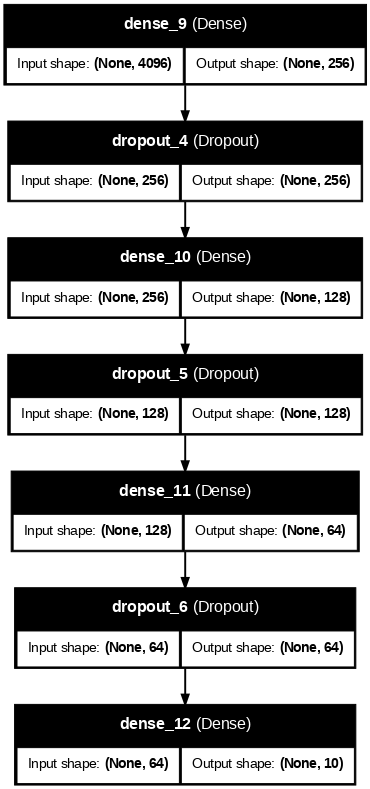

In [94]:

from tensorflow.keras.utils import plot_model

plot_model(
    four_layer_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)


###### 3.1.4 Model Comparison and Ensemble
Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?



In [95]:
# compare model params
params_single = single_layer_model.count_params()
params_two = two_layer_model.count_params()
params_four = four_layer_model.count_params()

print(f"Single-layer params : {params_single:,}")
print(f"Two-layer params    : {params_two:,}")
print(f"Four-layer params   : {params_four:,}")

print("\nMargins:")
print(f"Two - Single  : {params_two - params_single:,}")
print(f"Four - Two    : {params_four - params_two:,}")
print(f"Four - Single : {params_four - params_single:,}")

Single-layer params : 40,970
Two-layer params    : 525,706
Four-layer params   : 1,090,634

Margins:
Two - Single  : 484,736
Four - Two    : 564,928
Four - Single : 1,049,664


In [96]:
# compare accuracy
print(f"Single-Layer Test Accuracy        : {test_acc_single:.4f}")
print(f"Two-Layer Test Accuracy           : {test_acc_two:.4f}")
print(f"Four-Layer NN + Dropout Accuracy  : {test_acc_four:.4f}")

Single-Layer Test Accuracy        : 0.3055
Two-Layer Test Accuracy           : 0.3994
Four-Layer NN + Dropout Accuracy  : 0.3478


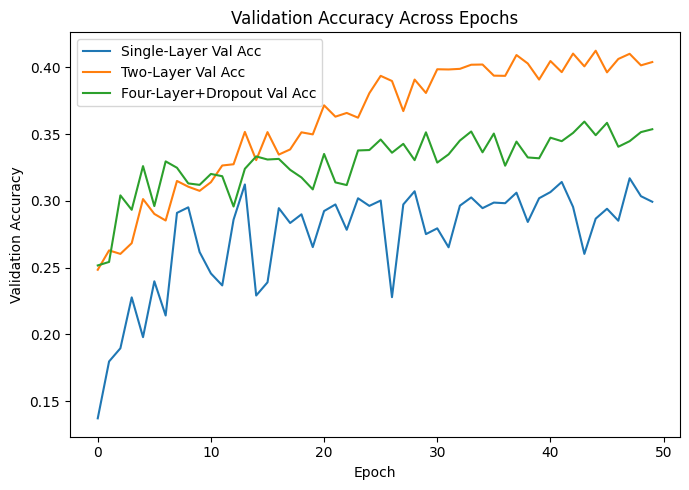

In [97]:
# compare epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history_single.history["val_accuracy"], label="Single-Layer Val Acc")
plt.plot(history_two.history["val_accuracy"], label="Two-Layer Val Acc")
plt.plot(history_four.history["val_accuracy"], label="Four-Layer+Dropout Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

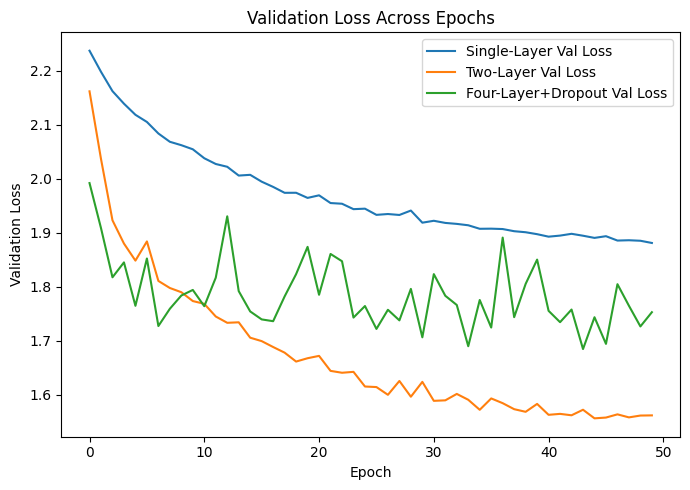

In [98]:
# compare log curves
plt.figure(figsize=(7, 5))

plt.plot(history_single.history["val_loss"], label="Single-Layer Val Loss")
plt.plot(history_two.history["val_loss"], label="Two-Layer Val Loss")
plt.plot(history_four.history["val_loss"], label="Four-Layer+Dropout Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
# build essemble
# predicted class probabilities on test set
pred_single = single_layer_model.predict(X_test_gray_flat_nn, verbose=0)
pred_two = two_layer_model.predict(X_test_gray_flat_nn, verbose=0)
pred_four = four_layer_model.predict(X_test_gray_flat_nn, verbose=0)

print(pred_single.shape, pred_two.shape, pred_four.shape)  # should all be (N, 10)


# simple average ensemble
pred_ensemble = (pred_single + pred_two + pred_four) / 3.0

# final predicted class
y_pred_ensemble = pred_ensemble.argmax(axis=1)

# if y_test_full is still integer labels, use directly
from sklearn.metrics import accuracy_score

ensemble_acc = accuracy_score(y_test_full, y_pred_ensemble)
print(f"Ensemble Test Accuracy: {ensemble_acc:.4f}")



print(f"Single-Layer Accuracy       : {test_acc_single:.4f}")
print(f"Two-Layer Accuracy          : {test_acc_two:.4f}")
print(f"Four-Layer + Dropout Acc    : {test_acc_four:.4f}")
print(f"Ensemble Accuracy           : {ensemble_acc:.4f}")

(10800, 10) (10800, 10) (10800, 10)
Ensemble Test Accuracy: 0.3916
Single-Layer Accuracy       : 0.3055
Two-Layer Accuracy          : 0.3994
Four-Layer + Dropout Acc    : 0.3478
Ensemble Accuracy           : 0.3916


#### 3.2 RGB Images
For this section, use the original RGB images.

3.2.1 CNN Model
Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?


In [45]:
from tqdm.notebook import tqdm

def build_rgb_dataset(sample_list, desc="Preparing RGB dataset"):
    X_rgb, y_out = [], []
    for path, lbl in tqdm(sample_list, desc=desc):
        ms = load_ms_array(path) # (13, H, W)
        rgb = ms_to_rgb(ms)    # (H, W, 3) - still raw values
        # Normalize RGB to [0, 1]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
        X_rgb.append(rgb)
        y_out.append(lbl)
    return np.stack(X_rgb), np.array(y_out, dtype=np.int32)

X_rgb_train_full, y_train_full_rgb = build_rgb_dataset(
    train_samples, desc="Preparing full TRAIN RGB dataset"
)
X_rgb_test_full, y_test_full_rgb = build_rgb_dataset(
    test_samples, desc="Preparing full TEST RGB dataset"
)

print("X_rgb_train_full shape:", X_rgb_train_full.shape)
print("X_rgb_test_full shape :", X_rgb_test_full.shape)
print("y_train_full_rgb shape     :", y_train_full_rgb.shape)
print("y_test_full_rgb shape      :", y_test_full_rgb.shape)


Preparing full TRAIN RGB dataset:   0%|          | 0/32400 [00:00<?, ?it/s]

Preparing full TEST RGB dataset:   0%|          | 0/10800 [00:00<?, ?it/s]

X_rgb_train_full shape: (32400, 64, 64, 3)
X_rgb_test_full shape : (10800, 64, 64, 3)
y_train_full_rgb shape     : (32400,)
y_test_full_rgb shape      : (10800,)


In [47]:
#shuffle training set for class balance across train and validation sets
from sklearn.utils import shuffle

X_rgb_train_full, y_train_full_rgb = shuffle(
    X_rgb_train_full,
    y_train_full_rgb,
    random_state=42
)

In [48]:
# One-hot encode the labels for the RGB dataset (y_train_full_rgb and y_test_full_rgb)
from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_cat_rgb = to_categorical(y_train_full_rgb, num_classes=num_classes)
y_test_cat_rgb = to_categorical(y_test_full_rgb, num_classes=num_classes)

print(y_train_cat_rgb.shape, y_test_cat_rgb.shape)


(32400, 10) (10800, 10)


In [38]:

import numpy as np

def check_class_balance(y, split_ratio=0.8):
    split_idx = int(len(y) * split_ratio)

    y_first = y[:split_idx]
    y_last  = y[split_idx:]

    def print_dist(name, y_subset):
        counts = np.bincount(y_subset)
        probs = counts / counts.sum()

        print(f"\n{name}:")
        for cls, p in enumerate(probs):
            print(f"Class {cls}: {p:.3f}")

    print_dist("First 80%", y_first)
    print_dist("Last 20%", y_last)

In [48]:
#sanity check
check_class_balance(np.argmax(y_train_cat_rgb, axis=1))


First 80%:
Class 0: 0.113
Class 1: 0.111
Class 2: 0.111
Class 3: 0.092
Class 4: 0.093
Class 5: 0.075
Class 6: 0.093
Class 7: 0.110
Class 8: 0.093
Class 9: 0.109

Last 20%:
Class 0: 0.105
Class 1: 0.111
Class 2: 0.111
Class 3: 0.094
Class 4: 0.092
Class 5: 0.071
Class 6: 0.092
Class 7: 0.115
Class 8: 0.091
Class 9: 0.118


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,196,618 (16.01 MB)

 Trainable params: 4,196,618 (16.01 MB)

 Non-trainable params: 0 (0.00 B)

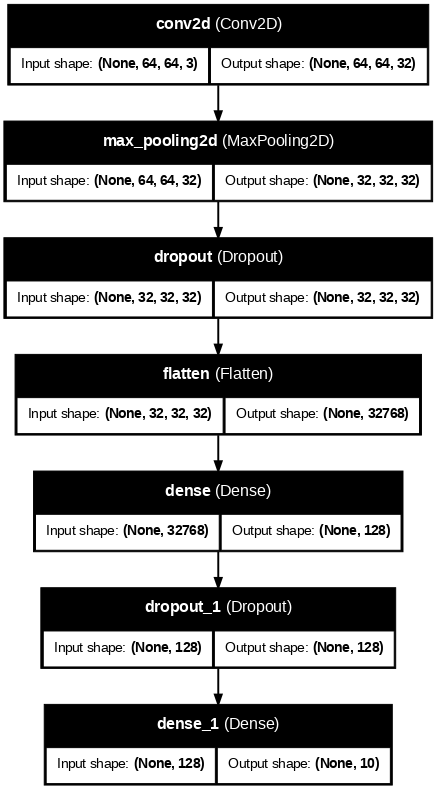

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

# Define the simplified CNN model with one of each specified layer type
cnn_model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)), # Input shape for RGB images

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'), # One Conv2D layer
    layers.MaxPooling2D((2, 2)), # One MaxPooling2D layer
    layers.Dropout(0.25), # One Dropout layer after pooling

    layers.Flatten(), # One Flatten layer

    layers.Dense(128, activation='relu'), # One Dense hidden layer
    layers.Dropout(0.5), # Added dropout before the last dense layer
    layers.Dense(num_classes, activation='softmax') # Output Dense layer
])

cnn_model.summary()

# Visualize the simplified model architecture
plot_model(
    cnn_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)


In [37]:
# Compile the CNN model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
# early_stop_cnn = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

history_cnn = cnn_model.fit(
    X_rgb_train_full,
    y_train_cat_rgb,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    shuffle=True,
    verbose=1
)


Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 119s 287ms/step - accuracy: 0.3480 - loss: 0.2818 - val_accuracy: 0.5190 - val_loss: 0.2160
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - accuracy: 0.4676 - loss: 0.2274 - val_accuracy: 0.5424 - val_loss: 0.1974
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 139s 255ms/step - accuracy: 0.5120 - loss: 0.2131 - val_accuracy: 0.5417 - val_loss: 0.1980
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 145s 262ms/step - accuracy: 0.5298 - loss: 0.2060 - val_accuracy: 0.6015 - val_loss: 0.1786
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 109s 268ms/step - accuracy: 0.5483 - loss: 0.1997 - val_accuracy: 0.6074 - val_loss: 0.1754
Epoch 6/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 103s 254ms/step - accuracy: 0.5568 - loss: 0.1961 - val_accuracy: 0.6245 - val_loss: 0.1695
Epoch 7/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 103s 253ms/step - accuracy: 0.5757 - loss: 0.1904 - val_accuracy: 0.6519 - val_loss: 0.1645
Epoch 8/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 147s 266ms/step - accuracy: 0.5894 -

In [50]:
# Evaluate the CNN model on the test data
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(
    X_rgb_test_full,
    y_test_cat_rgb,
    verbose=0
)

print(f"CNN Model Test Accuracy: {test_acc_cnn:.4f}")
print(f"CNN Model Test Loss: {test_loss_cnn:.4f}")


CNN Model Test Accuracy: 0.7246
CNN Model Test Loss: 0.1376


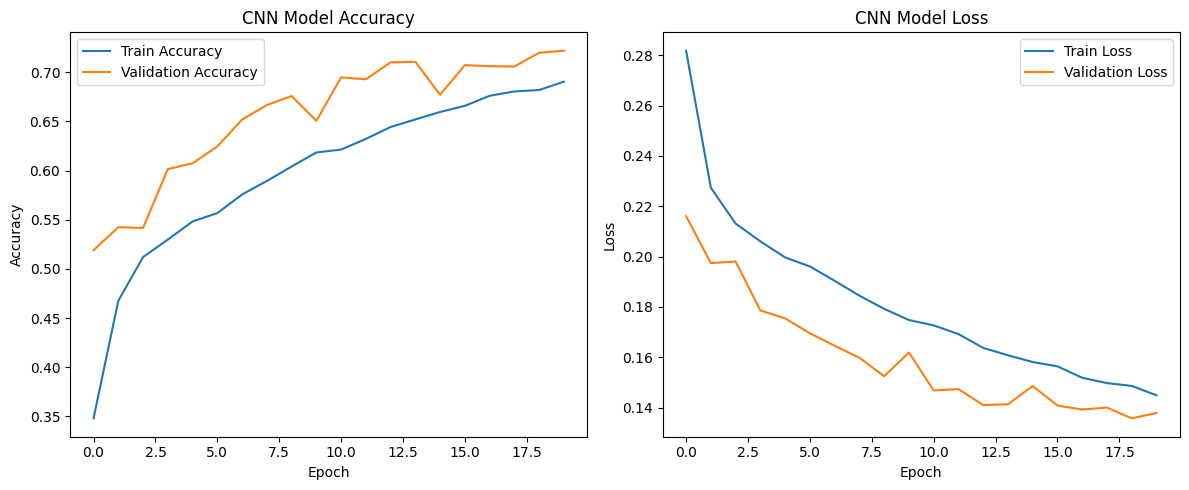

In [51]:
import matplotlib.pyplot as plt

# Plot training history for CNN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [92]:
import pickle

#save model
cnn_model.save("cnn_model_rgb.h5")

# Save history
with open("cnn_history_rgb.pkl", "wb") as f:
    pickle.dump(history_cnn.history, f)

In [100]:
# Compare CNN with previous models
print(f"Single-Layer NN Test Accuracy       : {test_acc_single:.4f}")
print(f"Two-Layer NN Test Accuracy          : {test_acc_two:.4f}")
print(f"Four-Layer NN with Dropout Accuracy : {test_acc_four:.4f}")
print(f"CNN Model Test Accuracy             : {test_acc_cnn:.4f}")


Single-Layer NN Test Accuracy       : 0.3055
Two-Layer NN Test Accuracy          : 0.3994
Four-Layer NN with Dropout Accuracy : 0.3478
CNN Model Test Accuracy             : 0.7246


3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

In [53]:
from tensorflow import keras
from tensorflow.keras import layers

advanced_cnn_model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation=None, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation=None, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax') # Adjusted for 10-class classification
])

advanced_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,118,858 (8.08 MB)

 Trainable params: 2,118,410 (8.08 MB)

 Non-trainable params: 448 (1.75 KB)

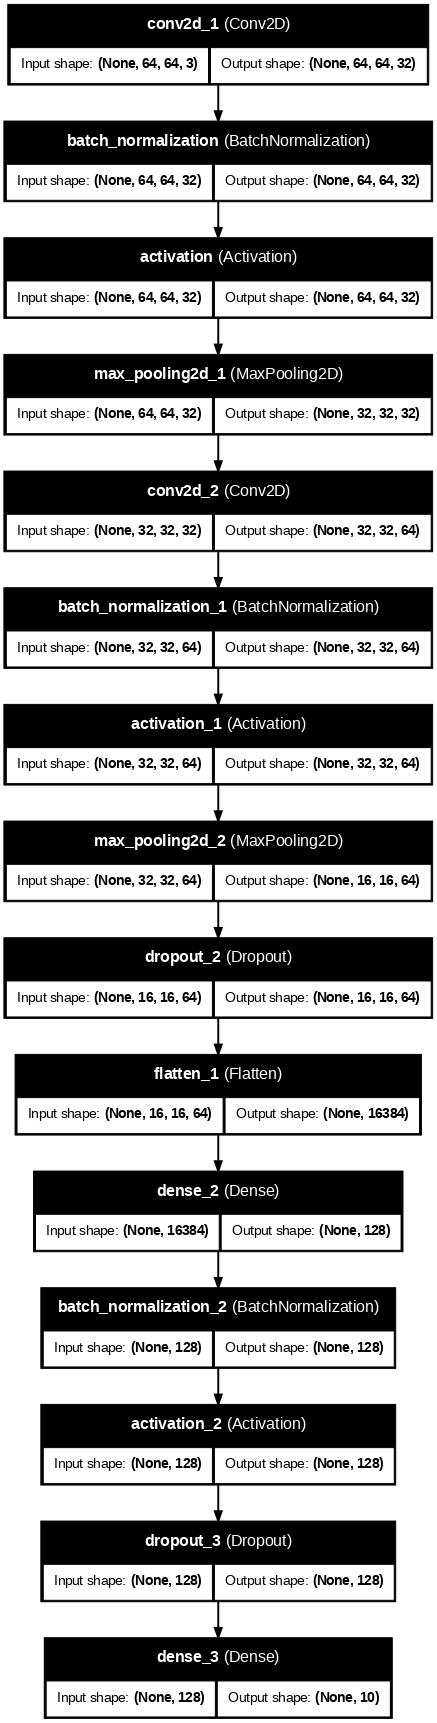

In [54]:
from tensorflow.keras.utils import plot_model

plot_model(
    advanced_cnn_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)

In [55]:
import tensorflow as tf

advanced_cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_advanced_cnn = EarlyStopping(
    monitor='val_loss',
    patience=10, # Increased patience for potentially deeper model
    restore_best_weights=True
)

history_advanced_cnn = advanced_cnn_model.fit(
    X_rgb_train_full, # Using original full RGB data
    y_train_cat_rgb,
    validation_split=0.2,
    epochs=100, # Increased epochs as early stopping will manage overfitting
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop_advanced_cnn],
    verbose=1
)

Epoch 1/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 292s 706ms/step - accuracy: 0.5312 - loss: 0.2418 - val_accuracy: 0.2035 - val_loss: 0.4404
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 280s 690ms/step - accuracy: 0.6988 - loss: 0.1504 - val_accuracy: 0.6843 - val_loss: 0.1458
Epoch 3/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 284s 703ms/step - accuracy: 0.7523 - loss: 0.1259 - val_accuracy: 0.6333 - val_loss: 0.1739
Epoch 4/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 289s 715ms/step - accuracy: 0.7890 - loss: 0.1110 - val_accuracy: 0.6520 - val_loss: 0.1718
Epoch 5/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 277s 684ms/step - accuracy: 0.8088 - loss: 0.1006 - val_accuracy: 0.5168 - val_loss: 0.2598
Epoch 6/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 330s 705ms/step - accuracy: 0.8320 - loss: 0.0907 - val_accuracy: 0.5377 - val_loss: 0.2545
Epoch 7/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 322s 706ms/step - accuracy: 0.8473 - loss: 0.0834 - val_accuracy: 0.6522 - val_loss: 0.1779
Epoch 8/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 315s 689ms/step - accuracy: 

Advanced CNN Model Test Accuracy: 0.8350
Advanced CNN Model Test Loss: 0.0903


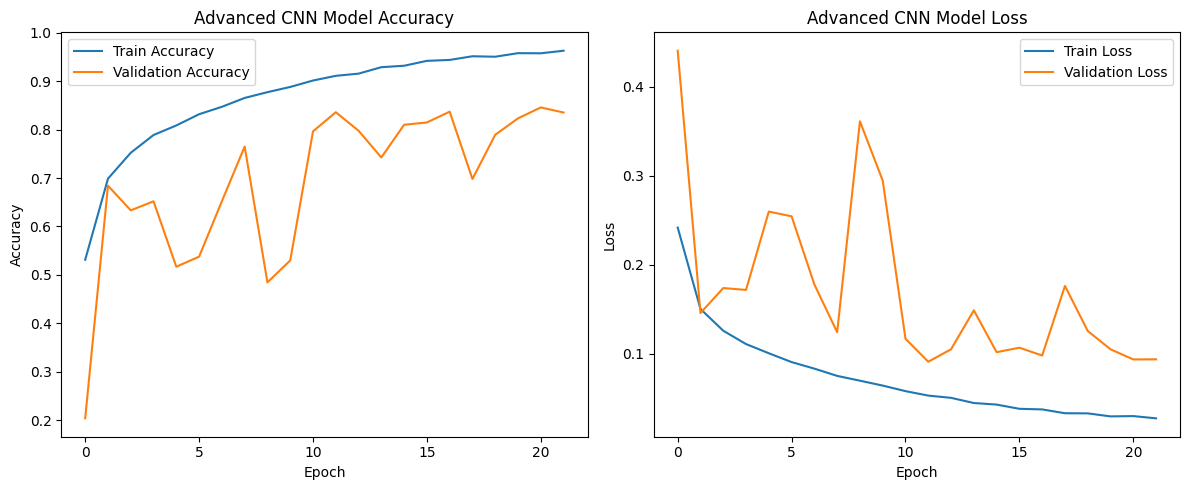

In [57]:
import matplotlib.pyplot as plt

# Evaluate the advanced CNN model on the test data
test_loss_advanced_cnn, test_acc_advanced_cnn = advanced_cnn_model.evaluate(
    X_rgb_test_full, # Using original full RGB data
    y_test_cat_rgb,
    verbose=0
)

print(f"Advanced CNN Model Test Accuracy: {test_acc_advanced_cnn:.4f}")
print(f"Advanced CNN Model Test Loss: {test_loss_advanced_cnn:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_advanced_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_advanced_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Advanced CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_advanced_cnn.history['loss'], label='Train Loss')
plt.plot(history_advanced_cnn.history['val_loss'], label='Validation Loss')
plt.title('Advanced CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

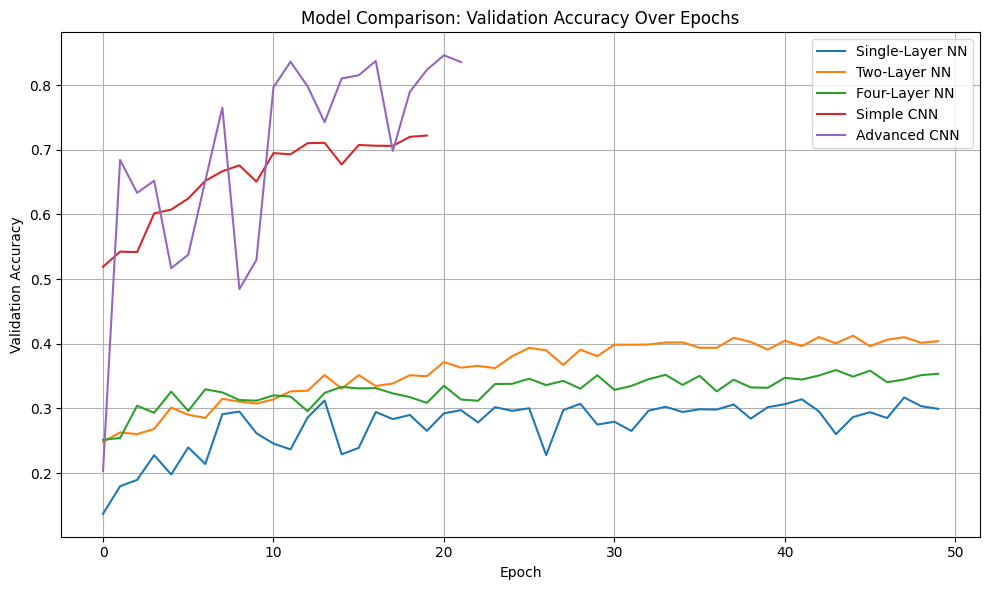

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history_single.history['val_accuracy'], label='Single-Layer NN')
plt.plot(history_two.history['val_accuracy'], label='Two-Layer NN')
plt.plot(history_four.history['val_accuracy'], label='Four-Layer NN')
plt.plot(history_cnn.history['val_accuracy'], label='Simple CNN')
plt.plot(history_advanced_cnn.history['val_accuracy'], label='Advanced CNN')

plt.title('Model Comparison: Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

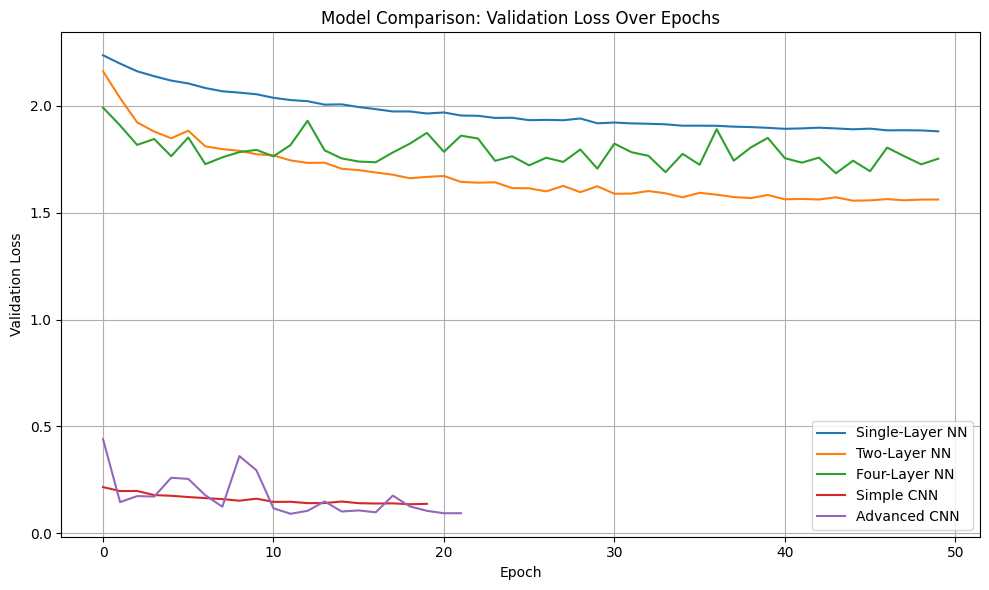

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history_single.history['val_loss'], label='Single-Layer NN')
plt.plot(history_two.history['val_loss'], label='Two-Layer NN')
plt.plot(history_four.history['val_loss'], label='Four-Layer NN')
plt.plot(history_cnn.history['val_loss'], label='Simple CNN')
plt.plot(history_advanced_cnn.history['val_loss'], label='Advanced CNN')

plt.title('Model Comparison: Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.



In [33]:
from tqdm.notebook import tqdm

def build_multispectral_dataset(sample_list, desc="Preparing Multispectral dataset"):
    X_ms, y_out = [], []
    # Bands: B04 (Red), B03 (Green), B02 (Blue), B08 (NIR)
    # Indices: 3, 2, 1, 7 (assuming 0-indexed multispectral array)
    SELECTED_BANDS = [3, 2, 1, 7]

    for path, lbl in tqdm(sample_list, desc=desc):
        ms = load_ms_array(path)  # (13, H, W)

        # Select desired bands and stack them (H, W, num_bands)
        selected_ms_bands = ms[SELECTED_BANDS, :, :]
        selected_ms_bands = np.transpose(selected_ms_bands, (1, 2, 0)) # (H, W, num_bands)

        # Normalize each band to [0, 1]
        normalized_ms = np.zeros_like(selected_ms_bands, dtype=np.float32)
        for i in range(selected_ms_bands.shape[-1]):
            band = selected_ms_bands[:, :, i]
            if band.max() - band.min() > 1e-6: # Avoid division by zero
                normalized_ms[:, :, i] = (band - band.min()) / (band.max() - band.min())
            else:
                normalized_ms[:, :, i] = 0.0 # Or some other reasonable default

        X_ms.append(normalized_ms)
        y_out.append(lbl)
    return np.stack(X_ms), np.array(y_out, dtype=np.int32)

print("Building multispectral datasets...")
X_ms_train_full, y_train_full_ms = build_multispectral_dataset(
    train_samples, desc="Preparing full TRAIN MS dataset"
)
X_ms_test_full, y_test_full_ms = build_multispectral_dataset(
    test_samples, desc="Preparing full TEST MS dataset"
)

print("\nX_ms_train_full shape:", X_ms_train_full.shape)
print("X_ms_test_full shape :", X_ms_test_full.shape)
print("y_train_full_ms shape     :", y_train_full_ms.shape)
print("y_test_full_ms shape      :", y_test_full_ms.shape)

Building multispectral datasets...


Preparing full TRAIN MS dataset:   0%|          | 0/32400 [00:00<?, ?it/s]

Preparing full TEST MS dataset:   0%|          | 0/10800 [00:00<?, ?it/s]


X_ms_train_full shape: (32400, 64, 64, 4)
X_ms_test_full shape : (10800, 64, 64, 4)
y_train_full_ms shape     : (32400,)
y_test_full_ms shape      : (10800,)


In [34]:
from sklearn.utils import shuffle

X_ms_train_full, y_train_full_ms = shuffle(
    X_ms_train_full,
    y_train_full_ms,
    random_state=42
)

print("Multispectral training data shuffled.")

Multispectral training data shuffled.


In [35]:
from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_cat_ms = to_categorical(y_train_full_ms, num_classes=num_classes)
y_test_cat_ms = to_categorical(y_test_full_ms, num_classes=num_classes)

print("Multispectral labels one-hot encoded.")
print("y_train_cat_ms shape:", y_train_cat_ms.shape)
print("y_test_cat_ms shape :", y_test_cat_ms.shape)

Multispectral labels one-hot encoded.
y_train_cat_ms shape: (32400, 10)
y_test_cat_ms shape : (10800, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,119,146 (8.08 MB)

 Trainable params: 2,118,698 (8.08 MB)

 Non-trainable params: 448 (1.75 KB)

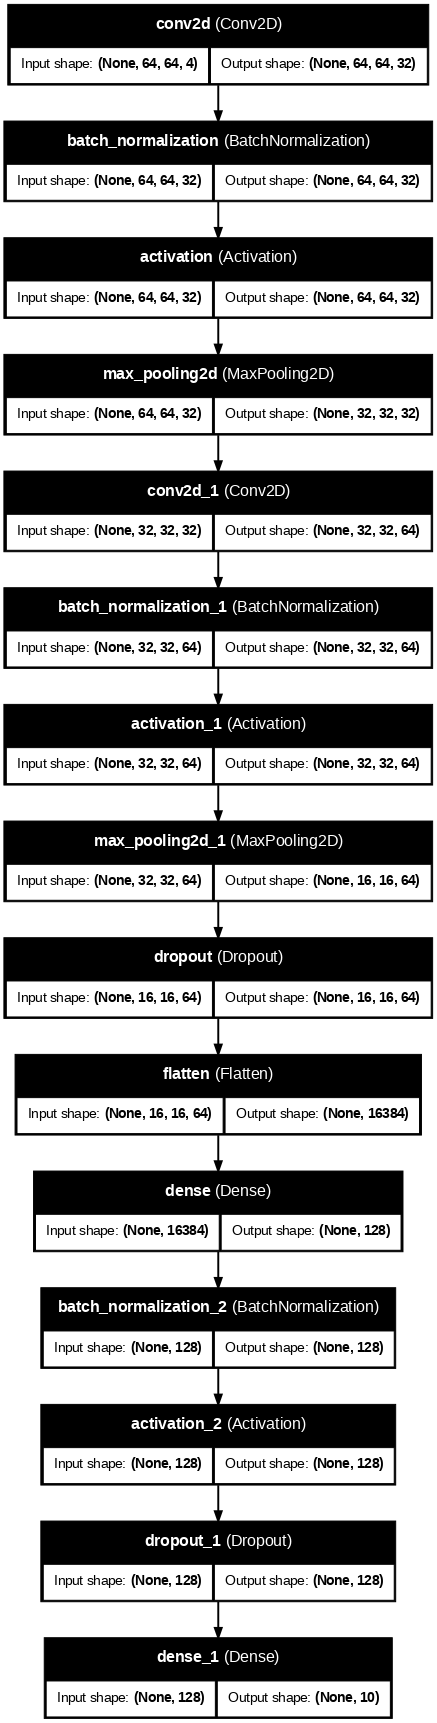

In [36]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

# Define a new Advanced CNN model for multispectral data
# Input shape now needs to reflect the number of selected bands (6 in this case)
advanced_cnn_ms_model = keras.Sequential([
    layers.Input(shape=(64, 64, X_ms_train_full.shape[-1])), # Dynamic input shape based on last dim of X_ms_train_full
    layers.Conv2D(32, (3, 3), activation=None, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation=None, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

advanced_cnn_ms_model.summary()

plot_model(
    advanced_cnn_ms_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70
)

In [37]:
import tensorflow as tf

advanced_cnn_ms_model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Binary cross-entropy for multi-label classification (one-hot encoded)
    metrics=['accuracy']
)

print("Advanced CNN for Multispectral data compiled.")

Advanced CNN for Multispectral data compiled.


In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_advanced_cnn_ms = EarlyStopping(
    monitor='val_loss',
    patience=10, # Increased patience for potentially deeper model
    restore_best_weights=True
)

history_advanced_cnn_ms = advanced_cnn_ms_model.fit(
    X_ms_train_full,
    y_train_cat_ms,
    validation_split=0.2,
    epochs=100, # Increased epochs as early stopping will manage overfitting
    batch_size=16, #reduce batch size to not overload RAM
    shuffle=True,
    callbacks=[early_stop_advanced_cnn_ms],
    verbose=1
)

print("Training of Advanced CNN for Multispectral data complete.")

Epoch 1/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 298s 179ms/step - accuracy: 0.5757 - loss: 0.2027 - val_accuracy: 0.6821 - val_loss: 0.1466
Epoch 2/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 282s 174ms/step - accuracy: 0.7269 - loss: 0.1373 - val_accuracy: 0.7571 - val_loss: 0.1228
Epoch 3/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 312s 168ms/step - accuracy: 0.7754 - loss: 0.1168 - val_accuracy: 0.7162 - val_loss: 0.1304
Epoch 4/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 278s 172ms/step - accuracy: 0.8090 - loss: 0.1036 - val_accuracy: 0.7420 - val_loss: 0.1349
Epoch 5/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 275s 170ms/step - accuracy: 0.8307 - loss: 0.0928 - val_accuracy: 0.6100 - val_loss: 0.2333
Epoch 6/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 276s 170ms/step - accuracy: 0.8485 - loss: 0.0829 - val_accuracy: 0.6937 - val_loss: 0.2073
Epoch 7/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 268s 165ms/step - accuracy: 0.8684 - loss: 0.0747 - val_accuracy: 0.8698 - val_loss: 0.0666
Epoch 8/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 268s 165ms/s

In [50]:
import pickle

#save model
advanced_cnn_ms_model.save("advanced_cnn_ms_model.h5")

# Save history
with open("history_advanced_cnn_ms.pkl", "wb") as f:
    pickle.dump(history_advanced_cnn_ms.history, f)

Advanced CNN Multispectral Model Test Accuracy: 0.9094
Advanced CNN Multispectral Model Test Loss: 0.0575


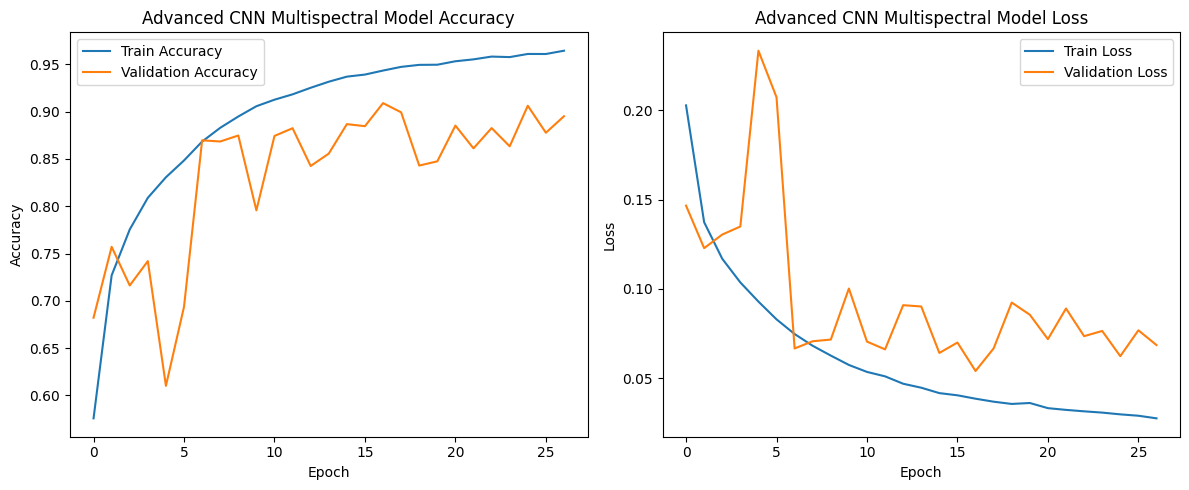

In [41]:
import matplotlib.pyplot as plt

# Evaluate the advanced CNN multispectral model on the test data
test_loss_advanced_cnn_ms, test_acc_advanced_cnn_ms = advanced_cnn_ms_model.evaluate(
    X_ms_test_full,
    y_test_cat_ms,
    verbose=0
)

print(f"Advanced CNN Multispectral Model Test Accuracy: {test_acc_advanced_cnn_ms:.4f}")
print(f"Advanced CNN Multispectral Model Test Loss: {test_loss_advanced_cnn_ms:.4f}")

# Plot training history for the multispectral model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_advanced_cnn_ms.history['accuracy'], label='Train Accuracy')
plt.plot(history_advanced_cnn_ms.history['val_accuracy'], label='Validation Accuracy')
plt.title('Advanced CNN Multispectral Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_advanced_cnn_ms.history['loss'], label='Train Loss')
plt.plot(history_advanced_cnn_ms.history['val_loss'], label='Validation Loss')
plt.title('Advanced CNN Multispectral Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

338/338 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step


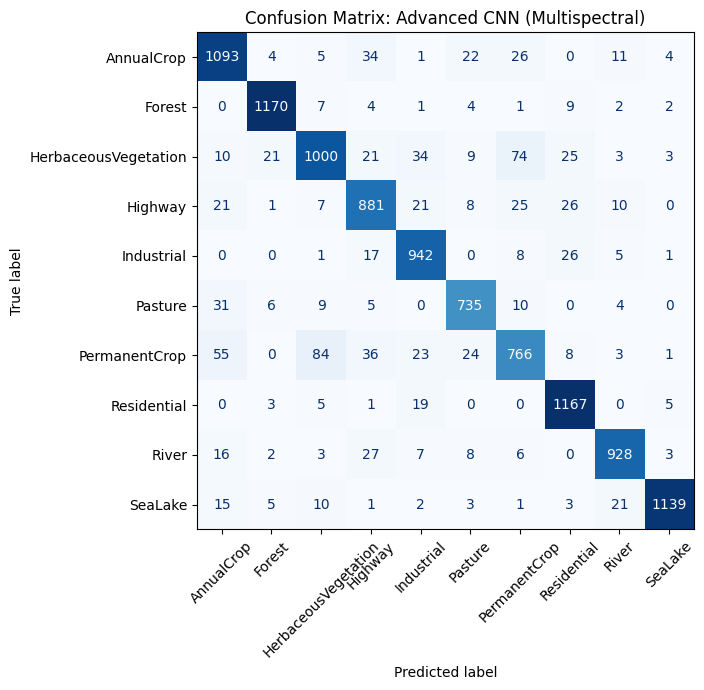

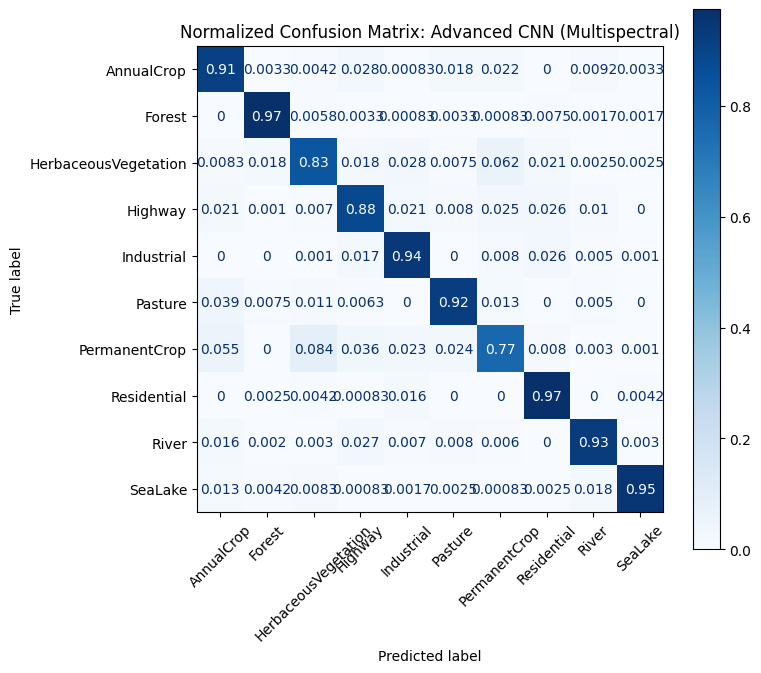

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions (probabilities)
y_pred_probs = advanced_cnn_ms_model.predict(X_ms_test_full)

# 2. Convert to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Convert true labels from one-hot to class indices
y_true = np.argmax(y_test_cat_ms, axis=1)

# 4. Define label order and names (all 10 classes)
label_order = list(range(10))
label_names = [classes[i] for i in label_order]

# 5. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_order)

# 6. Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix: Advanced CNN (Multispectral)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Optional: Normalized version (very useful for analysis) ----
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=label_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp_norm.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Normalized Confusion Matrix: Advanced CNN (Multispectral)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

338/338 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step
Class         Acc   Prec Recall    AUC
AnnualCrop 0.911 0.881 0.911 0.993
Forest     0.975 0.965 0.975 0.999
HerbaceousVegetation 0.833 0.884 0.833 0.990
Highway    0.881 0.858 0.881 0.987
Industrial 0.942 0.897 0.942 0.997
Pasture    0.919 0.904 0.919 0.997
PermanentCrop 0.766 0.835 0.766 0.982
Residential 0.973 0.923 0.973 0.999
River      0.928 0.940 0.928 0.995
SeaLake    0.949 0.984 0.949 0.999

Macro F1 score (all classes): 0.907


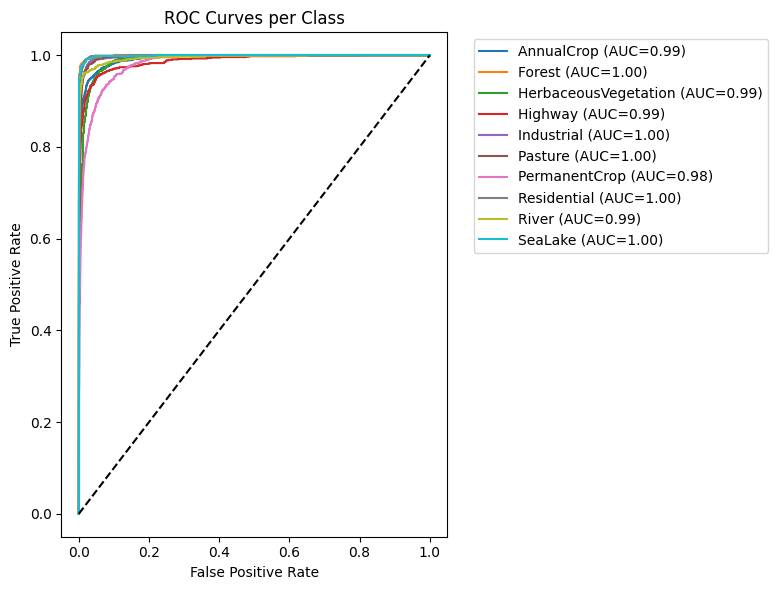

In [43]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
import matplotlib.pyplot as plt

# Convert predictions and true labels to class indices
y_true = np.argmax(y_test_cat_ms, axis=1)
y_pred_probs = advanced_cnn_ms_model.predict(X_ms_test_full)
y_pred = np.argmax(y_pred_probs, axis=1)

num_classes = y_test_cat_ms.shape[1]

# Store per-class metrics
per_class_accuracy = []
per_class_precision = []
per_class_recall = []
per_class_auc = []

for i in range(num_classes):
    # Mask for class i
    mask = (y_true == i)

    # Accuracy on samples of this class
    acc = accuracy_score(y_true[mask], y_pred[mask])

    # Precision & recall (one-vs-all)
    prec = precision_score(y_true == i, y_pred == i, average='binary', zero_division=0)
    rec = recall_score(y_true == i, y_pred == i, average='binary', zero_division=0)

    # AUC using probabilities
    try:
        auc_score = roc_auc_score(y_test_cat_ms[:, i], y_pred_probs[:, i])
    except ValueError:  # if class i missing in test set
        auc_score = np.nan

    per_class_accuracy.append(acc)
    per_class_precision.append(prec)
    per_class_recall.append(rec)
    per_class_auc.append(auc_score)

# Compute macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')

# Print per-class metrics
print(f"{'Class':<10} {'Acc':>6} {'Prec':>6} {'Recall':>6} {'AUC':>6}")
for i in range(num_classes):
    print(f"{classes[i]:<10} {per_class_accuracy[i]:.3f} {per_class_precision[i]:.3f} {per_class_recall[i]:.3f} {per_class_auc[i]:.3f}")

print(f"\nMacro F1 score (all classes): {macro_f1:.3f}")

# Optional: Plot ROC curves for all classes
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_cat_ms[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Class")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [49]:
import pickle
from tensorflow.keras.models import load_model
import numpy as np

# ---- 1. Load the saved RGB CNN model ----
cnn_model_rgb = load_model("cnn_model_rgb.h5")

# ---- 2. Load the saved training history ----
with open("cnn_history_rgb.pkl", "rb") as f:
    history_cnn_rgb = pickle.load(f)

# ---- 3. Evaluate on test data ----
test_loss_rgb, test_acc_rgb = cnn_model_rgb.evaluate(X_rgb_test_full, y_test_cat_rgb, verbose=0)

print(f"CNN RGB Test Accuracy: {test_acc_rgb:.4f}")
print(f"CNN RGB Test Loss: {test_loss_rgb:.4f}")

# ---- 4. Compare with multispectral CNN ----
test_loss_ms, test_acc_ms = advanced_cnn_ms_model.evaluate(X_ms_test_full, y_test_cat_ms, verbose=0)
print(f"Advanced CNN Multispectral Test Accuracy: {test_acc_ms:.4f}")
print(f"Advanced CNN Multispectral Test Loss: {test_loss_ms:.4f}")

# ---- 5. Quick comparison ----
accuracy_diff = test_acc_ms - test_acc_rgb
print(f"Accuracy improvement using multispectral vs RGB: {accuracy_diff:.4f}")

CNN RGB Test Accuracy: 0.7246
CNN RGB Test Loss: 0.1376
Advanced CNN Multispectral Test Accuracy: 0.9094
Advanced CNN Multispectral Test Loss: 0.0575
Accuracy improvement using multispectral vs RGB: 0.1847
